# Курсовая — пайплайн экспериментов

**Оптимизация кредитных решений на основе машинного обучения и экономической функции прибыли.**

### Содержание
- **Блок 0.** Импорты и конфигурация.
- **Блок 1.** Подготовка данных (загрузка, survival-разметка, канонические срезы, признаки). Без моделей.
- **Блок 1.5.** Диагностика цензурирования (§3.1): доля потерь тела по зрелости.
- **Блок 2.** Наивная постановка — наивная строка Табл. 3.2 (GBM/LR на loan-level).
- **Блок 3.** Hazard-PD@36 — hazard-строка Табл. 3.2 (GBM/LR, дискретный хазард).
- **Блок 4.** Калибровка PD@36 (изотоническая; Brier/ECE/KS; сравнение калибраторов).

Блок 5 (денежная модель / H2) и проверки §3.4.1, §3.5, §3.6, ablation, кластерный вывод
навешиваются на канонические объекты ядра (`pd36_gbm_cal`, `surv_test`).

**Запуск:** свежее ядро, строго сверху вниз. Требуется `../data/accepted_2007_to_2018Q4.csv`.
`SEED=42`

## Блок 0. Импорты и конфигурация

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, brier_score_loss
import matplotlib.pyplot as plt

# Подавляем ТОЛЬКО заведомо доброкачественные категории предупреждений,
# а не все подряд: настоящие проблемы (деление на ноль, переполнение в
# pv_comp) остаются видимыми.
warnings.simplefilter('default')
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)
np.seterr(divide='warn', over='warn', invalid='warn', under='ignore')

pd.set_option('display.width', 120); pd.set_option('display.max_columns', 40)

# === Централизованная конфигурация эксперимента (§2.8): единый источник истины ===
# Все магические числа собраны здесь; ячейки ниже ссылаются на эти константы.
SEED      = 42                              # единое зерно всех источников случайности
H         = 36                             # горизонт оценки вероятности дефолта, мес.
SNAPSHOT  = pd.Timestamp('2018-12-31')      # дата среза дампа accepted_2007_to_2018Q4
DATA      = '../data/accepted_2007_to_2018Q4.csv'   # путь к исходному дампу Lending Club

Q_SUB     = 0.15                            # доля подвыборки не-событий в person-period (case-control)
LGD_BASE  = 0.50                            # базовый LGD параметрической функции прибыли
DISC_BASE = 0.03                            # базовая ставка дисконтирования δ (стоимость капитала)
DMF_BASE  = 0.15                            # базовый момент дефолта m (доля срока)
BUDGETS   = [0.10, 0.30, 0.50]             # доли капитала для H2-отбора портфеля (Табл. 3.4)
LGD_GRID  = [0.45, 0.50, 0.55]             # сетка LGD для проверки устойчивости (§3.6)
M_GRID    = [0.10, 0.15, 0.25, 0.40]       # сетка момента дефолта m, доля срока (§3.6)
B_MAIN    = 2000                            # число бутстрэп-реплик для основных ДИ
B_AUX     = 500                             # число бутстрэп-реплик для вспомогательных ДИ


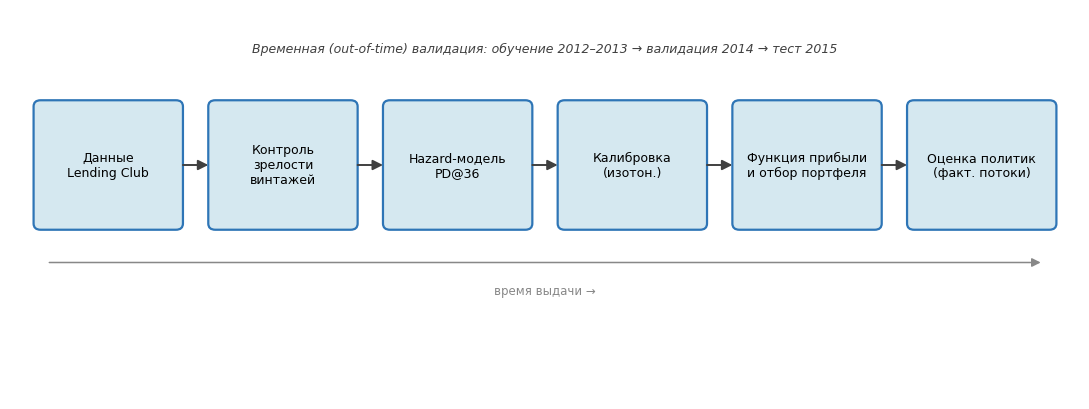

In [2]:
# Рис. 2.1 — схема пайплайна исследования
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
labels = ['Данные\nLending Club', 'Контроль\nзрелости\nвинтажей', 'Hazard-модель\nPD@36',
          'Калибровка\n(изотон.)', 'Функция прибыли\nи отбор портфеля', 'Оценка политик\n(факт. потоки)']
n = len(labels); w, h, gap, x0, yc, pad = 1.55, 1.5, 0.45, 0.35, 3.0, 0.08
xs = [x0 + i*(w + gap) for i in range(n)]; xlim = xs[-1] + w + x0
fig, ax = plt.subplots(figsize=(11, 4.2)); ax.set_xlim(0, xlim); ax.set_ylim(0, 5); ax.axis('off')
for x, t in zip(xs, labels):
    ax.add_patch(FancyBboxPatch((x, yc - h/2), w, h, boxstyle=f"round,pad={pad}", fc='#D5E8F0', ec='#2E75B6', lw=1.6))
    ax.text(x + w/2, yc, t, ha='center', va='center', fontsize=9)
for i in range(n - 1):                                  # стрелки от края до края бокса, по центру
    ax.add_patch(FancyArrowPatch((xs[i]+w+pad, yc), (xs[i+1]-pad, yc),
                 arrowstyle='-|>', mutation_scale=15, color='#404040', lw=1.4, shrinkA=0, shrinkB=0))
ax.text(xlim/2, 4.45, 'Временная (out-of-time) валидация: обучение 2012–2013 → валидация 2014 → тест 2015',
        ha='center', fontsize=9, style='italic', color='#404040')
ax.add_patch(FancyArrowPatch((xs[0]+0.1, 1.75), (xs[-1]+w-0.1, 1.75),
             arrowstyle='-|>', mutation_scale=13, color='#888', lw=1.1, shrinkA=0, shrinkB=0))
ax.text(xlim/2, 1.35, 'время выдачи →', ha='center', fontsize=8.5, color='#888')
fig.tight_layout(); fig.savefig('../reports/fig_pipeline.png', dpi=150); plt.show()

## Блок 1. Подготовка данных
Только загрузка, разметка и разбиение — без моделей. Создаются: `surv` (survival-кадр со всеми
пригодными кредитами, незавершённые — как цензурированные), `df_completed` (наивная loan-level
выборка завершённых) и канонические срезы по годам.

In [3]:
# Единая загрузка. surv = все пригодные кредиты (живые + завершённые):
#   event=1  — наблюдён дефолт (Charged Off / Default);
#   mob      — месяцев на книге к дате среза;
#   duration — прожитые месяцы (прокси total_pymnt/installment), ограниченные сроком кредита;
# незавершённые входят как правосторонне цензурированные (нужно для hazard-PD и денежной метрики).
NEEDED = ['id','loan_status','issue_d','loan_amnt','int_rate','term','installment','grade','sub_grade',
 'emp_length','home_ownership','annual_inc','verification_status','purpose','dti',
 'delinq_2yrs','fico_range_low','fico_range_high','inq_last_6mths','open_acc',
 'pub_rec','revol_bal','revol_util','total_acc','application_type','mort_acc','pub_rec_bankruptcies',
 'total_pymnt','recoveries','total_rec_int','total_rec_prncp']
surv = pd.read_csv(DATA, usecols=lambda c: c in NEEDED, low_memory=False)
surv = surv[surv['loan_status'].notna()].copy()
surv['int_rate']    = pd.to_numeric(surv['int_rate'].astype(str).str.rstrip('%').str.strip(), errors='coerce')
surv['term_months'] = pd.to_numeric(surv['term'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
surv['issue_date']  = pd.to_datetime(surv['issue_d'], format='%b-%Y', errors='coerce')
surv = surv[surv['issue_date'].notna() & surv['term_months'].notna() & surv['installment'].gt(0)].copy()
surv['issue_year']  = surv['issue_date'].dt.year

DEFAULT_STATUS = ['Charged Off','Default','Does not meet the credit policy. Status:Charged Off']
PAID_STATUS    = ['Fully Paid','Does not meet the credit policy. Status:Fully Paid']
surv['event']    = surv['loan_status'].isin(DEFAULT_STATUS).astype(int)
surv['mob']      = ((SNAPSHOT.year-surv['issue_date'].dt.year)*12
                    + (SNAPSHOT.month-surv['issue_date'].dt.month)).clip(lower=0)
surv['mpaid']    = ((surv['total_pymnt'] - surv['recoveries'].fillna(0)) / surv['installment']).round()
surv['duration'] = np.where(surv['loan_status'].isin(DEFAULT_STATUS+PAID_STATUS), surv['mpaid'], surv['mob'])
surv['duration'] = surv['duration'].clip(lower=1).combine(surv['term_months'], min)   # не больше срока
print(f'surv: {len(surv):,} кредитов | наблюдённых дефолтов {surv["event"].mean()*100:.1f}%')

surv: 2,260,668 кредитов | наблюдённых дефолтов 11.9%


In [4]:
# Наивная (loan-level) выборка для наивной строки Табл. 3.2: ТОЛЬКО завершённые кредиты,
# без контроля зрелости; цель — пожизненный дефолт. Незрелые кредиты здесь НЕ отбрасываются,
# что и даёт завышенный AUC (часть сигнала — артефакт цензурирования, см. §3.1/§3.2 работы).
NAIVE_COMPLETED = ['Fully Paid','Charged Off','Default']
df_completed = surv[surv['loan_status'].isin(NAIVE_COMPLETED)].copy()
df_completed['default'] = df_completed['loan_status'].isin(['Charged Off','Default']).astype(int)
print(f'df_completed (наивная): {len(df_completed):,} | дефолтов {df_completed["default"].mean()*100:.1f}%')

df_completed (наивная): 1,345,350 | дефолтов 20.0%


In [5]:
# Признаки уровня кредита (известны на момент заявки; post-application поля — total_pymnt,
# recoveries, total_rec_* — НЕ входят в признаки, чтобы исключить утечку, и используются только
# в §3.1 и в денежной метрике Блока 5).
NUM_FEATURES = ['loan_amnt','int_rate','term_months','annual_inc','dti','delinq_2yrs','fico_range_low',
    'fico_range_high','inq_last_6mths','open_acc','pub_rec','revol_bal','revol_util','total_acc',
    'mort_acc','pub_rec_bankruptcies']
CAT_FEATURES = ['grade','sub_grade','emp_length','home_ownership','verification_status','purpose','application_type']

def build_loan_matrix(df, base_cols):
    """Матрица признаков уровня кредита: числовые + one-hot категориальные.
    base_cols=None — задать опорный набор колонок по обучающей выборке; иначе выровнять по нему
    (reindex с нулями), чтобы train/valid/test совпадали по столбцам."""
    X = pd.concat([df[NUM_FEATURES].reset_index(drop=True),
                   pd.get_dummies(df[CAT_FEATURES].astype(str).reset_index(drop=True), drop_first=True)], axis=1)
    return X if base_cols is None else X.reindex(columns=base_cols, fill_value=0)

def y_default_within_H(df):
    """Целевая PD@36: дефолт наблюдён И произошёл в пределах горизонта H месяцев."""
    return ((df['event'].values == 1) & (df['duration'].values <= H)).astype(int)

# Канонические срезы (определяются ОДИН раз и далее только читаются — никаких переопределений te/tr):
surv_train  = surv[surv['issue_year'].isin([2012, 2013])]    # обучение hazard/LR
surv_valid  = surv[surv['issue_year'] == 2014]               # калибровка
surv_test   = surv[surv['issue_year'] == 2015]               # тест
naive_train = df_completed[df_completed['issue_year'].isin([2012, 2013])]
naive_test  = df_completed[df_completed['issue_year'] == 2015]
print(f'surv:  train={len(surv_train):,}  valid={len(surv_valid):,}  test={len(surv_test):,}')
print(f'naive: train={len(naive_train):,}  test={len(naive_test):,}')

surv:  train=188,181  valid=235,629  test=421,095
naive: train=188,171  test=375,546


In [6]:
print(f"lifetime-дефолт наивной выборки 2015: {naive_test['default'].mean()*100:.1f}%")

lifetime-дефолт наивной выборки 2015: 20.2%


In [7]:
# === Проверка тождества денежной метрики (для §2.5.1) ===
# total_pymnt == total_rec_prncp + total_rec_int + total_rec_late_fee + recoveries ?
_cols = ['loan_status','total_pymnt','total_rec_prncp','total_rec_int',
         'total_rec_late_fee','recoveries']
n_all=hit_w=hit_wo=n_co=hit_cw=hit_cwo=n_rec=0          # счётчики (int)
res_sum=0.0; res_max=0.0
for _ch in pd.read_csv(DATA, usecols=_cols, low_memory=False, chunksize=200_000):
    _ch=_ch[_ch['loan_status'].notna()]
    for _c in _cols[1:]: _ch[_c]=pd.to_numeric(_ch[_c],errors='coerce')
    _ch=_ch.dropna(subset=_cols[1:])
    if len(_ch)==0: continue
    tp =_ch['total_pymnt'].values
    aw =(_ch['total_rec_prncp']+_ch['total_rec_int']+_ch['total_rec_late_fee']+_ch['recoveries']).values
    awo=(_ch['total_rec_prncp']+_ch['total_rec_int']+_ch['total_rec_late_fee']).values
    tol=np.maximum(1.0,1e-3*np.abs(tp))
    n_all+=len(_ch); hit_w+=int((np.abs(tp-aw)<=tol).sum()); hit_wo+=int((np.abs(tp-awo)<=tol).sum())
    res_sum+=float(np.abs(tp-aw).sum()); res_max=max(res_max,float(np.abs(tp-aw).max()))
    co=_ch['loan_status'].str.contains('Charged Off',na=False).values
    n_co+=int(co.sum()); n_rec+=int((_ch['recoveries'].values[co]>0).sum())
    hit_cw +=int((np.abs(tp[co]-aw[co]) <=tol[co]).sum())
    hit_cwo+=int((np.abs(tp[co]-awo[co])<=tol[co]).sum())
print(f"Вся выборка (n={n_all:,}): С recoveries {100*hit_w/n_all:.2f}% | БЕЗ {100*hit_wo/n_all:.2f}% | "
      f"ср.|ост.| ${res_sum/n_all:.4f} | max ${res_max:.2f}")
print(f"Charged Off (n={n_co:,}; recoveries>0 у {100*n_rec/n_co:.1f}%): "
      f"С recoveries {100*hit_cw/n_co:.2f}% | БЕЗ {100*hit_cwo/n_co:.2f}%")

Вся выборка (n=2,260,668): С recoveries 100.00% | БЕЗ 92.04% | ср.|ост.| $0.0009 | max $0.01
Charged Off (n=269,320; recoveries>0 у 68.9%): С recoveries 100.00% | БЕЗ 33.21%


## Блок 1.5. Диагностика цензурирования (§3.1, Рис. 3.1 / Табл. 3.1)
Реализованная доля потерь тела по дефолтным кредитам в разрезе «год выдачи × зрелость».

In [8]:
diag = surv.copy()
diag['matured']   = diag['mob'] >= diag['term_months']
diag['loss_body'] = ((diag['loan_amnt'] - diag['total_rec_prncp'] - diag['recoveries'].fillna(0))
                     / diag['loan_amnt']).clip(0, 1)
co = diag['event'] == 1                                  # только дефолтные кредиты
print('Доля потерь тела по году выдачи × зрелость (False=незрелые, True=зрелые):')
print(diag[co].groupby(['issue_year','matured'])['loss_body'].mean()
      .unstack('matured').round(3).loc[2013:2018].to_string())
print('\nСредние recoveries на дефолтный кредит по году выдачи:')
print(diag[co].groupby('issue_year')['recoveries'].mean().round(0).loc[2013:2018].to_string())

Доля потерь тела по году выдачи × зрелость (False=незрелые, True=зрелые):
matured     False  True 
issue_year              
2013          NaN  0.545
2014        0.620  0.495
2015        0.678  0.508
2016        0.633    NaN
2017        0.751    NaN
2018        0.890    NaN

Средние recoveries на дефолтный кредит по году выдачи:
issue_year
2013    1323.0
2014    1355.0
2015    1301.0
2016    1210.0
2017    1081.0
2018     555.0


In [9]:
comp = surv[surv['loan_status'].isin(NAIVE_COMPLETED)].copy()
comp['matured'] = comp['mob'] >= comp['term_months']
share = (1 - comp.groupby('issue_year')['matured'].mean()).loc[2014:2018].round(2)
print("Доля незрелых среди завершённых по году выдачи:"); print(share.to_string())

Доля незрелых среди завершённых по году выдачи:
issue_year
2014    0.27
2015    0.25
2016    1.00
2017    1.00
2018    1.00


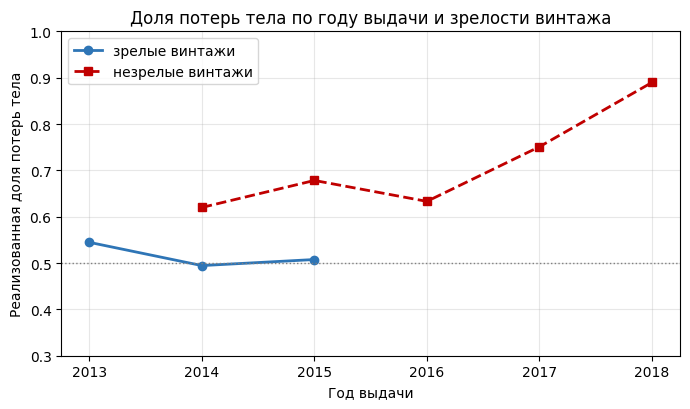

In [10]:
# Рис. 3.1 — реализованная доля потерь тела по году выдачи и зрелости
tbl = diag[co].groupby(['issue_year','matured'])['loss_body'].mean().unstack('matured').loc[2013:2018]
fig, ax = plt.subplots(figsize=(7, 4.2))
if True  in tbl.columns: ax.plot(tbl.index, tbl[True],  'o-',  color='#2E75B6', lw=2, label='зрелые винтажи')
if False in tbl.columns: ax.plot(tbl.index, tbl[False], 's--', color='#C00000', lw=2, label='незрелые винтажи')
ax.axhline(0.50, color='gray', ls=':', lw=1)
ax.set_xlabel('Год выдачи'); ax.set_ylabel('Реализованная доля потерь тела')
ax.set_title('Доля потерь тела по году выдачи и зрелости винтажа')
ax.set_ylim(0.3, 1.0); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig('../reports/fig_3_1_loss_body.png', dpi=150); plt.show()

## Блок 2. Наивная постановка — наивная строка Табл. 3.2
Loan-level классификатор пожизненного дефолта на завершённых кредитах (без контроля зрелости).
Имена с суффиксом `_naive`, чтобы их нельзя было перепутать с hazard-объектами.

In [11]:
# Матрицы наивной постановки (опорные колонки — по обучающей выборке).
Xtr_naive  = build_loan_matrix(naive_train, None)
naive_cols = list(Xtr_naive.columns)
Xte_naive  = build_loan_matrix(naive_test, naive_cols)
ytr_naive  = naive_train['default'].values
yte_naive  = naive_test['default'].values
assert Xtr_naive.shape[1] == Xte_naive.shape[1] == len(naive_cols)
assert len(Xtr_naive) == len(ytr_naive) and len(Xte_naive) == len(yte_naive)
print(f'naive: Xtr={Xtr_naive.shape}, Xte={Xte_naive.shape}')

# GBM наивной постановки
gbm_naive = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
    min_child_samples=100, random_state=SEED, verbose=-1).fit(Xtr_naive, ytr_naive)
pred_gbm_naive = gbm_naive.predict_proba(Xte_naive)[:, 1]

# LR наивной постановки (импутация медианой + стандартизация; nan_to_num защищает от вырожденных
# one-hot столбцов с нулевой дисперсией, дающих inf после стандартизации)
imp_naive = SimpleImputer(strategy='median').fit(Xtr_naive.values.astype(float))
sc_naive  = StandardScaler().fit(imp_naive.transform(Xtr_naive.values.astype(float)))
std_naive = lambda X: np.nan_to_num(sc_naive.transform(imp_naive.transform(X.values.astype(float))),
                                    nan=0., posinf=0., neginf=0.)
lr_naive = LogisticRegression(solver='lbfgs', max_iter=2000, C=1.0, random_state=SEED)
lr_naive.fit(std_naive(Xtr_naive), ytr_naive)
pred_lr_naive = lr_naive.predict_proba(std_naive(Xte_naive))[:, 1]

auc_gbm_naive = roc_auc_score(yte_naive, pred_gbm_naive)
auc_lr_naive  = roc_auc_score(yte_naive, pred_lr_naive)

# Бутстрэп-ДИ для ΔAUC (GBM − LR) на уровне кредитов
rng = np.random.default_rng(SEED); Nn = len(yte_naive); dboot = []
for _ in range(2000):
    ix = rng.integers(0, Nn, Nn)
    if yte_naive[ix].min() == yte_naive[ix].max(): continue
    dboot.append(roc_auc_score(yte_naive[ix], pred_gbm_naive[ix]) - roc_auc_score(yte_naive[ix], pred_lr_naive[ix]))
lo, hi = np.percentile(dboot, [2.5, 97.5])
print(f'НАИВНАЯ (loan-level, тест 2015, n={Nn:,}): GBM={auc_gbm_naive:.4f}  LR={auc_lr_naive:.4f}')
print(f'  ΔAUC(GBM-LR) = {auc_gbm_naive-auc_lr_naive:+.4f}  95%CI[{lo:+.4f}; {hi:+.4f}]')

naive: Xtr=(188171, 85), Xte=(375546, 85)


/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn

НАИВНАЯ (loan-level, тест 2015, n=375,546): GBM=0.7181  LR=0.7262
  ΔAUC(GBM-LR) = -0.0081  95%CI[-0.0091; -0.0072]


## Блок 3. Hazard-PD@36 — hazard-строка Табл. 3.2
Дискретная hazard-модель: кредиты разворачиваются в «кредит-месяц», PD@36 собирается как
1 − Π(1 − hazard). Имена с суффиксом `_hazard` / `pd36_*`. Калибровка вынесена в Блок 4.

In [12]:
def expand_person_period(df, base_cols, q=Q_SUB, seed=SEED):
    """Разворот кредитов в «кредит-месяц» до min(дефолт, H). Сохраняем ВСЕ месяцы-события и
    подвыборку не-событий с долей q; веса 1/q возвращают несмещённость хазарда (case-control).
    Последний столбец матрицы — mob (месяц на книге), задающий форму базового хазарда."""
    df = df.reset_index(drop=True); dur = df['duration'].values
    ev_H = ((df['event'].values == 1) & (dur <= H)).astype(int)   # событие только в пределах горизонта
    T = np.clip(np.minimum(dur, H).astype(int), 1, H)
    idx = np.repeat(np.arange(len(df)), T)
    mob = np.ones(int(T.sum()), int); mob[np.cumsum(T)[:-1]] -= T[:-1]; mob = np.cumsum(mob)
    y = ((mob == np.repeat(T, T)) & (np.repeat(ev_H, T) == 1)).astype(np.int8)
    rng_e = np.random.default_rng(seed)
    keep = (y == 1) | (rng_e.random(len(y)) < q)
    w = np.where(y[keep] == 1, 1.0, 1.0/q).astype(np.float32)
    Xl = build_loan_matrix(df, base_cols).astype(np.float32).values
    Xpp = np.column_stack([Xl[idx[keep]], mob[keep].astype(np.float32)])
    return Xpp, y[keep], w

hazard_cols = list(build_loan_matrix(surv_train, None).columns)        # опорные колонки признаков
Xtr_hazard, ytr_hazard, wtr_hazard = expand_person_period(surv_train, hazard_cols)
Xva_hazard, yva_hazard, wva_hazard = expand_person_period(surv_valid, hazard_cols)
assert Xtr_hazard.shape[1] == Xva_hazard.shape[1] == len(hazard_cols) + 1   # +1 = столбец mob
print(f'person-period: train={Xtr_hazard.shape}, valid={Xva_hazard.shape}, доля событий={ytr_hazard.mean()*100:.2f}%')

# GBM-hazard (ранняя остановка по валидации 2014)
gbm_hazard = lgb.LGBMClassifier(n_estimators=600, learning_rate=0.05, num_leaves=63,
    min_child_samples=200, random_state=SEED, verbose=-1)
gbm_hazard.fit(Xtr_hazard, ytr_hazard, sample_weight=wtr_hazard,
    eval_set=[(Xva_hazard, yva_hazard)], eval_sample_weight=[wva_hazard],
    callbacks=[lgb.early_stopping(50, verbose=False)])

# LR-hazard (импутация + стандартизация; решатель saga — как в работе)
imp_hazard = SimpleImputer(strategy='median').fit(Xtr_hazard)
sc_hazard  = StandardScaler().fit(imp_hazard.transform(Xtr_hazard))
lr_hazard  = LogisticRegression(solver='saga', max_iter=2000, n_jobs=-1, random_state=SEED)
lr_hazard.fit(sc_hazard.transform(imp_hazard.transform(Xtr_hazard)), ytr_hazard, sample_weight=wtr_hazard)

def survival_pd36(month_hazard, df):
    """PD@36 = 1 - произведение (1 - hazard_t) по t=1..H. month_hazard(X) — P(дефолт в месяце t).
    Производительность: матрица «кредит × месяц» собирается один раз и подаётся в month_hazard
    ОДНИМ вызовом (вместо H последовательных predict_proba), затем берётся произведение по месяцам."""
    Xl = build_loan_matrix(df, hazard_cols).astype(np.float32).values; nrow = len(df)
    months = np.repeat(np.arange(1, H+1, dtype=np.float32), nrow)       # [1×nrow, 2×nrow, …, H×nrow]
    tiled  = np.column_stack([np.tile(Xl, (H, 1)), months])            # (nrow·H, p+1)
    haz    = month_hazard(tiled).reshape(H, nrow)                      # строка t-1 = hazard месяца t
    return 1 - np.prod(1 - haz, axis=0)

pd36_gbm = survival_pd36(lambda X: gbm_hazard.predict_proba(X)[:, 1], surv_test)
pd36_lr  = survival_pd36(lambda X: lr_hazard.predict_proba(sc_hazard.transform(imp_hazard.transform(X)))[:, 1], surv_test)
y36_test = y_default_within_H(surv_test)
assert len(pd36_gbm) == len(pd36_lr) == len(y36_test) == len(surv_test)

auc_gbm_hazard = roc_auc_score(y36_test, pd36_gbm)
auc_lr_hazard  = roc_auc_score(y36_test, pd36_lr)
print(f'\nHAZARD PD@36 (тест 2015, n={len(y36_test):,}): средняя PD={pd36_gbm.mean()*100:.1f}%  '
      f'факт дефолт@36={y36_test.mean()*100:.1f}%')
print(f'  GBM={auc_gbm_hazard:.4f}  LR={auc_lr_hazard:.4f}')
for trm in (36, 60):
    msk = surv_test['term_months'].values == trm
    if msk.sum() > 500:
        print(f'  AUC@36 срок {trm} мес.: {roc_auc_score(y36_test[msk], pd36_gbm[msk]):.4f}  (n={int(msk.sum()):,})')

person-period: train=(940600, 86), valid=(1173792, 86), доля событий=2.92%


/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b



HAZARD PD@36 (тест 2015, n=421,095): средняя PD=13.5%  факт дефолт@36=17.6%
  GBM=0.6915  LR=0.6893
  AUC@36 срок 36 мес.: 0.6837  (n=283,173)
  AUC@36 срок 60 мес.: 0.6709  (n=137,922)


In [13]:
# Бутстрэп-ДИ для ΔAUC (GBM - LR) и тест эквивалентности TOST (порог ±0.005 AUC)
rng = np.random.default_rng(SEED); Nh = len(y36_test); dboot_h = []
for _ in range(2000):
    ix = rng.integers(0, Nh, Nh)
    dboot_h.append(roc_auc_score(y36_test[ix], pd36_gbm[ix]) - roc_auc_score(y36_test[ix], pd36_lr[ix]))
lo95, hi95 = np.percentile(dboot_h, [2.5, 97.5])
lo90, hi90 = np.percentile(dboot_h, [5, 95])
delta = auc_gbm_hazard - auc_lr_hazard
print(f'ΔAUC(GBM-LR) hazard = {delta:+.4f}  95%CI[{lo95:+.4f}; {hi95:+.4f}]')
equiv = (lo90 > -0.005) and (hi90 < 0.005)
print(f'TOST ±0.005: 90% ДИ [{lo90:+.4f}; {hi90:+.4f}] -> '
      f'{"практическая эквивалентность" if equiv else "эквивалентность не доказана"}')

ΔAUC(GBM-LR) hazard = +0.0022  95%CI[+0.0014; +0.0030]
TOST ±0.005: 90% ДИ [+0.0015; +0.0029] -> практическая эквивалентность


In [14]:
# === Блок 3 (доп.): Random Forest (бэггинг) как третий класс модели — для Табл. 3.2a ===
# Переиспуем панель «кредит-месяц» Блока 3 и ту же сборку survival_pd36; тот же тест 2015.
# LR и GBM берём из Блока 3 выше, чтобы AUC совпали с Табл. 3.2.
from sklearn.ensemble import RandomForestClassifier

rf_hazard = RandomForestClassifier(
    n_estimators=200, min_samples_leaf=200, max_features='sqrt',
    n_jobs=-1, random_state=SEED)
rf_hazard.fit(Xtr_hazard, ytr_hazard, sample_weight=wtr_hazard)

pd36_rf = survival_pd36(lambda X: rf_hazard.predict_proba(X)[:, 1], surv_test)
auc_rf_hazard = roc_auc_score(y36_test, pd36_rf)

aucs = {'Логистическая регрессия (линейная)': auc_lr_hazard,
        'Random Forest (бэггинг)':            auc_rf_hazard,
        'LightGBM (бустинг)':                 auc_gbm_hazard}
rng_auc = max(aucs.values()) - min(aucs.values())

print(f'=== Табл. 3.2a — AUC@36, тест 2015, hazard-PD@36 (n={len(y36_test):,}) ===')
for name, a in aucs.items():
    print(f'  {name:<38} AUC@36 = {a:.4f}')
print(f'  Размах AUC@36 по трём классам моделей = {rng_auc:.4f}')

=== Табл. 3.2a — AUC@36, тест 2015, hazard-PD@36 (n=421,095) ===
  Логистическая регрессия (линейная)     AUC@36 = 0.6893
  Random Forest (бэггинг)                AUC@36 = 0.6927
  LightGBM (бустинг)                     AUC@36 = 0.6915
  Размах AUC@36 по трём классам моделей = 0.0034


### Важность признаков GBM-hazard (диагностика)

In [15]:
# Топ-15 признаков по встроенной метрике важности LightGBM (gain). Диагностика для §3.2: mob и финансовые признаки доминируют.
import pandas as pd
fi = pd.Series(gbm_hazard.feature_importances_, index=hazard_cols+['mob']).sort_values(ascending=False)
print(fi.head(15).to_string())

mob                       1079
annual_inc                 901
loan_amnt                  813
revol_bal                  800
dti                        739
revol_util                 697
int_rate                   655
fico_range_low             411
total_acc                  400
open_acc                   394
mort_acc                   324
inq_last_6mths             255
term_months                123
purpose_small_business     114
home_ownership_RENT         78


## Блок 4. Калибровка PD@36
Изотоническая регрессия учится на валидации 2014 и применяется к тесту 2015. Будучи монотонной,
она не меняет ранжирование (AUC/KS), но снижает ошибку калибровки (Brier/ECE).
Канонический выход — `pd36_gbm_cal` (вход для денежной модели Блока 5).

In [16]:
y36_valid      = y_default_within_H(surv_valid)
pd36_gbm_valid = survival_pd36(lambda X: gbm_hazard.predict_proba(X)[:, 1], surv_valid)
iso_calibrator = IsotonicRegression(out_of_bounds='clip').fit(pd36_gbm_valid, y36_valid)
pd36_gbm_cal   = iso_calibrator.transform(pd36_gbm)
assert len(pd36_gbm_cal) == len(pd36_gbm)

def ece(y, p, bins=10):
    """Expected Calibration Error: средняя |факт − прогноз| по 10 равным бинам вероятности."""
    edges = np.linspace(0, 1, bins+1); e = 0.0; nn = len(y)
    for lo, hi in zip(edges[:-1], edges[1:]):
        msk = (p >= lo) & ((p < hi) if hi < 1 else (p <= hi))
        if msk.sum(): e += msk.sum()/nn * abs(y[msk].mean() - p[msk].mean())
    return e

def ks_stat(y, p):
    """Колмогоров–Смирнов между распределениями скоров дефолтных и недефолтных."""
    o = np.argsort(p); ys = y[o]
    cb = np.cumsum(ys)/max(ys.sum(), 1); cg = np.cumsum(1-ys)/max((1-ys).sum(), 1)
    return float(np.max(np.abs(cb - cg)))

print(f"{'метрика':>7} | {'до калибр.':>10} | {'после изот.':>11}")
print(f"{'Brier':>7} | {brier_score_loss(y36_test, pd36_gbm):>10.4f} | {brier_score_loss(y36_test, pd36_gbm_cal):>11.4f}")
print(f"{'ECE':>7} | {ece(y36_test, pd36_gbm):>10.4f} | {ece(y36_test, pd36_gbm_cal):>11.4f}")
print(f"{'KS':>7} | {ks_stat(y36_test, pd36_gbm):>10.4f} | {ks_stat(y36_test, pd36_gbm_cal):>11.4f}")
print(f"{'AUC':>7} | {roc_auc_score(y36_test, pd36_gbm):>10.4f} | {roc_auc_score(y36_test, pd36_gbm_cal):>11.4f}")
print('Монотонная калибровка не меняет AUC/KS, корректирует Brier/ECE.')

/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


метрика | до калибр. | после изот.
  Brier |     0.1372 |      0.1359
    ECE |     0.0410 |      0.0250
     KS |     0.2768 |      0.2767
    AUC |     0.6915 |      0.6914
Монотонная калибровка не меняет AUC/KS, корректирует Brier/ECE.


In [17]:
# Сравнение калибраторов (изотоническая / Платт / Beta) на тесте 2015
def beta_feats(p, eps=1e-6):
    p = np.clip(p, eps, 1-eps); return np.column_stack([np.log(p), -np.log(1-p)])
platt_cal = LogisticRegression(solver='lbfgs', max_iter=5000, random_state=SEED).fit(pd36_gbm_valid.reshape(-1,1), y36_valid)
beta_cal  = LogisticRegression(solver='lbfgs', max_iter=5000, random_state=SEED).fit(beta_feats(pd36_gbm_valid), y36_valid)
variants = [('без калибровки', pd36_gbm),
            ('изотоническая',  pd36_gbm_cal),
            ('Платт',          platt_cal.predict_proba(pd36_gbm.reshape(-1,1))[:,1]),
            ('Beta',           beta_cal.predict_proba(beta_feats(pd36_gbm))[:,1])]
print(f"{'калибратор':>16} | {'Brier':>7} | {'ECE':>7} | {'AUC':>7} | {'ср.PD,%':>8}")
for nm, p in variants:
    print(f'{nm:>16} | {brier_score_loss(y36_test, p):>7.4f} | {ece(y36_test, p):>7.4f} | '
          f'{roc_auc_score(y36_test, p):>7.4f} | {p.mean()*100:>8.2f}')

/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vyumalashko/Desktop/coursewo

      калибратор |   Brier |     ECE |     AUC |  ср.PD,%
  без калибровки |  0.1372 |  0.0410 |  0.6915 |    13.51
   изотоническая |  0.1359 |  0.0250 |  0.6914 |    15.10
           Платт |  0.1367 |  0.0331 |  0.6915 |    15.42
            Beta |  0.1359 |  0.0250 |  0.6915 |    15.10


In [18]:
rng = np.random.default_rng(SEED); N = len(y36_test); dB, dE = [], []
for _ in range(2000):
    ix = rng.integers(0, N, N); yb = y36_test[ix]
    dB.append(brier_score_loss(yb, pd36_gbm_cal[ix]) - brier_score_loss(yb, pd36_gbm[ix]))
    dE.append(ece(yb, pd36_gbm_cal[ix]) - ece(yb, pd36_gbm[ix]))
dB, dE = np.array(dB), np.array(dE)
b0 = brier_score_loss(y36_test, pd36_gbm_cal) - brier_score_loss(y36_test, pd36_gbm)
e0 = ece(y36_test, pd36_gbm_cal) - ece(y36_test, pd36_gbm)
print(f'ΔBrier = {b0:+.4f}  95%ДИ[{np.percentile(dB,2.5):+.4f}; {np.percentile(dB,97.5):+.4f}]')
print(f'ΔECE   = {e0:+.4f}  95%ДИ[{np.percentile(dE,2.5):+.4f}; {np.percentile(dE,97.5):+.4f}]')

ΔBrier = -0.0013  95%ДИ[-0.0013; -0.0012]
ΔECE   = -0.0160  95%ДИ[-0.0161; -0.0159]


In [19]:
rng = np.random.default_rng(SEED); Nv = len(y36_valid); B = 200
briers, eces, means = [], [], []
m_run = np.zeros(len(pd36_gbm)); M2 = np.zeros(len(pd36_gbm)); cnt = 0      # Welford для sd на кредит
for _ in range(B):
    ix = rng.integers(0, Nv, Nv)
    iso_b = IsotonicRegression(out_of_bounds='clip').fit(pd36_gbm_valid[ix], y36_valid[ix])
    pred = iso_b.transform(pd36_gbm)
    briers.append(brier_score_loss(y36_test, pred)); eces.append(ece(y36_test, pred)); means.append(pred.mean())
    cnt += 1; d = pred - m_run; m_run += d/cnt; M2 += d*(pred - m_run)
sd_loan = np.sqrt(M2/(cnt-1))
print(f'Brier  [{min(briers):.4f}; {max(briers):.4f}]')
print(f'ECE    [{min(eces):.4f}; {max(eces):.4f}]')
print(f'ср.PD  [{min(means)*100:.1f}%; {max(means)*100:.1f}%]')
print(f'ср. sd калибр. PD на кредит = {sd_loan.mean()*100:.2f} п.п.')

Brier  [0.1358; 0.1361]
ECE    [0.0235; 0.0266]
ср.PD  [14.9%; 15.3%]
ср. sd калибр. PD на кредит = 0.43 п.п.


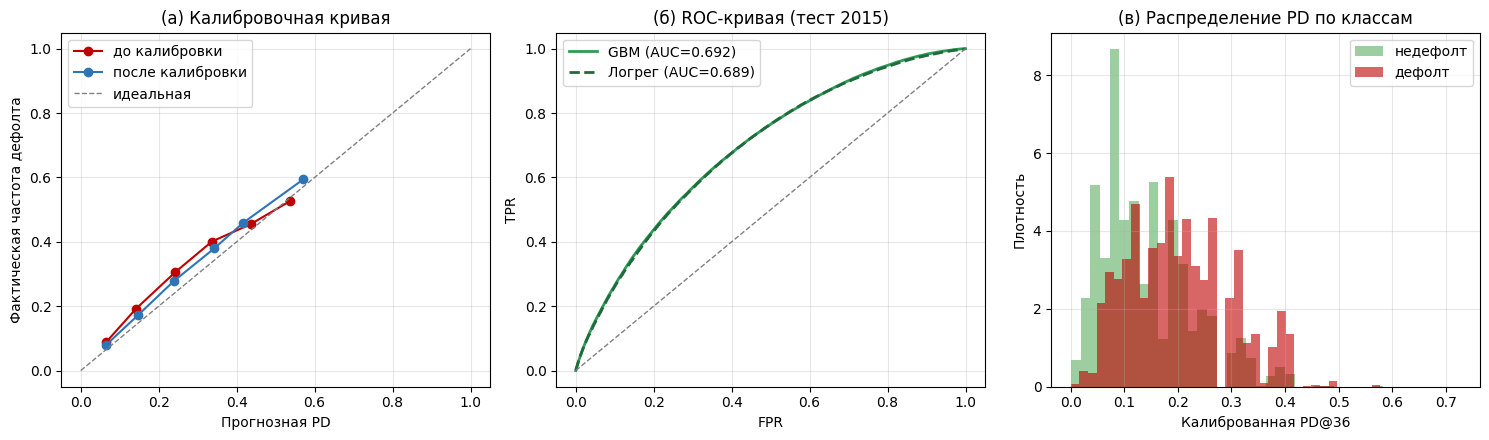

In [20]:
# Рис. 3.2 — (а) калибровка, (б) ROC, (в) распределение PD@36
from sklearn.metrics import roc_curve, roc_auc_score
def _cal_curve(y, p, bins=10, min_n=100):
    edges = np.linspace(0, 1, bins+1); xs, ys = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (p >= lo) & ((p < hi) if hi < 1 else (p <= hi))
        if m.sum() >= min_n:                      # отбрасываем почти пустые корзины хвоста
            xs.append(p[m].mean()); ys.append(y[m].mean())
    return np.array(xs), np.array(ys)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
xb, yb = _cal_curve(y36_test, pd36_gbm); xa, ya = _cal_curve(y36_test, pd36_gbm_cal)
axes[0].plot(xb, yb, 'o-', color='#C00000', label='до калибровки')
axes[0].plot(xa, ya, 'o-', color='#2E75B6', label='после калибровки')
axes[0].plot([0,1],[0,1],'--',color='gray',lw=1,label='идеальная')
axes[0].set_xlabel('Прогнозная PD'); axes[0].set_ylabel('Фактическая частота дефолта')
axes[0].set_title('(а) Калибровочная кривая'); axes[0].legend(); axes[0].grid(alpha=0.3)
for p, c, ls, lab in [(pd36_gbm,'#2E9B57','-','GBM'), (pd36_lr,'#1F6B3B','--','Логрег')]:
    fpr, tpr, _ = roc_curve(y36_test, p)
    axes[1].plot(fpr, tpr, ls, color=c, lw=2, label=f'{lab} (AUC={roc_auc_score(y36_test, p):.3f})')
axes[1].plot([0,1],[0,1],'--',color='gray',lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_title('(б) ROC-кривая (тест 2015)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].hist(pd36_gbm_cal[y36_test==0], bins=40, density=True, alpha=0.6, color='#5AAE61', label='недефолт')
axes[2].hist(pd36_gbm_cal[y36_test==1], bins=40, density=True, alpha=0.6, color='#C00000', label='дефолт')
axes[2].set_xlabel('Калиброванная PD@36'); axes[2].set_ylabel('Плотность')
axes[2].set_title('(в) Распределение PD по классам'); axes[2].legend(); axes[2].grid(alpha=0.3)
fig.tight_layout(); fig.savefig('../reports/fig_3_2_pd_quality.png', dpi=150); plt.show()

---
Блоки 5–7 навешиваются на канонические объекты ядра (`surv`, `surv_test`, `pd36_gbm_cal`)
и не переопределяют их:
- **Блок 5 (денежная модель, H2, §3.4):** дозревшая денежная выборка (`money_*`), `cashflow_good/bad`,
  `profit_score`/`risk_score`, бюджетная таблица; вырождение допуска (§3.3).
- **Проверки:** риск-скорректированное сравнение (§3.4.1), репликация 2014 (§3.5), H3 (§3.6),
  ablation источника выигрыша (Табл. 3.6), кластерный вывод, 60-мес сплит, перебор гиперпараметров.

## Блок 5. Денежная модель — вырождение допуска (§3.3) и отбор портфеля (H2, §3.4)
Все денежные расчёты идут на **дозревшей** выборке (завершённые И дожившие до срока кредиты) и на
калиброванной hazard-PD `pd36_gbm_cal` из Блока 4. Уникальные имена `money_*`, `profit_score`,
`risk_score`. Реализованный поток net = total_pymnt − loan_amnt — недисконтированный (total_pymnt уже включает recoveries)

In [21]:
# 5.1 Дозревшая денежная выборка + параметрическая функция прибыли
RES_OK = ['Fully Paid','Charged Off','Default',
          'Does not meet the credit policy. Status:Fully Paid',
          'Does not meet the credit policy. Status:Charged Off']

def money_slice(df, pd_cal):
    """Завершённые И дожившие до своего срока кредиты (контроль зрелости обязателен для денежной
    метрики). Возвращает массивы суммы L, ставки r, срока n, реализованного потока net,
    калиброванной PD и факта дефолта@36."""
    mob = df['mob'].values; term = df['term_months'].values
    mask = (mob >= term) & df['loan_status'].isin(RES_OK).values
    L = df['loan_amnt'].values[mask].astype(float)
    return dict(mask=mask, L=L,
        r   = df['int_rate'].values[mask] / 100,
        n   = df['term_months'].values[mask].astype(float),
        net = df['total_pymnt'].values[mask] - L,  # total_pymnt уже включает recoveries
        pd_cal = pd_cal[mask],
        yv  = ((df['event'].values[mask] == 1) & (df['duration'].values[mask] <= H)).astype(int))

money = money_slice(surv_test, pd36_gbm_cal)
L, r, n_term, net = money['L'], money['r'], money['n'], money['net']
pd_money, yv_money = money['pd_cal'], money['yv']
assert len(L) == len(r) == len(n_term) == len(net) == len(pd_money) == len(yv_money)
print(f"Дозревшая денежная выборка теста 2015: n={money['mask'].sum():,} | "
      f"60-мес среди них {(n_term==60).mean()*100:.1f}% | дефолт@36 {yv_money.mean()*100:.1f}%")

def pv_comp(L, r, n, lgd=LGD_BASE, disc=DISC_BASE, dmf=DMF_BASE):
    """Ожидаемая приведённая прибыль: возвращает (π_good, π_def).
    π_good — полностью выплаченный кредит; π_def — дефолт на месяце m=dmf·срок с возвратом доли
    (1−lgd) остатка тела. disc — ставка дисконтирования δ (стоимость капитала), dmf — момент дефолта."""
    i = r/12.; dd = disc/12.
    A = np.where(i>0, L*i/(1-(1+i)**(-n)), L/n)                 # аннуитетный платёж
    def ann(x, k):
        x = np.asarray(x, float)*np.ones_like(k); return np.where(x>0, (1-(1+x)**(-k))/x, k)
    pvg = A*ann(dd, n) - L
    m  = np.clip(np.floor(dmf*n), 0, n)
    Bm = np.where(i>0, A*(1-(1+i)**(-(n-m)))/i, L*(n-m)/n)      # остаток тела на момент дефолта
    pvd = A*ann(dd, m) + (1-lgd)*Bm*(1+dd)**(-m) - L
    return pvg, pvd

# === Единые помощники отбора портфеля (DRY, §2.8) ====================================
# Соглашение о знаке — единое во всём денежном блоке: скор всегда «больше = лучше»,
# отбор кандидатов = argsort(-score). Для риск-отбора «больше = лучше» означает -PD.
def portfolio_select(order, loan_amt, budget, total=None):
    """Индексы, отобранные порядком `order`, пока накопленная сумма ≤ budget·total."""
    if total is None: total = loan_amt.sum()
    return order[np.cumsum(loan_amt[order]) <= budget * total]

def portfolio_flow(order, loan_amt, net_cf, budget, total=None):
    """Реализованный поток (млн $) портфеля, набранного по `order` до доли капитала `budget`."""
    return net_cf[portfolio_select(order, loan_amt, budget, total)].sum() / 1e6

def bootstrap_gain(score, risk_score, loan_amt, net_cf, budget, B=B_MAIN, rng=None, seed=SEED):
    """Бутстрэп-распределение выигрыша потока (млн $) отбора по `score` над отбором по
    `risk_score` (оба — в соглашении «больше = лучше»): ресэмпл кредитов с возвращением,
    портфель пересобирается на каждой реплике. Возвращает массив из B разностей потоков.
    Если передан rng — использует его (для сохранения общей последовательности случайности)."""
    if rng is None: rng = np.random.default_rng(seed)
    n = len(loan_amt); gains = np.empty(B)
    for j in range(B):
        ix = rng.integers(0, n, n)
        La, na, sa, ra = loan_amt[ix], net_cf[ix], score[ix], risk_score[ix]; tt = La.sum()
        o1 = np.argsort(-sa); o2 = np.argsort(-ra)
        gains[j] = (na[o1[np.cumsum(La[o1]) <= budget*tt]].sum()
                    - na[o2[np.cumsum(La[o2]) <= budget*tt]].sum()) / 1e6
    return gains


Дозревшая денежная выборка теста 2015: n=283,026 | 60-мес среди них 0.0% | дефолт@36 14.9%


### 5.2 Вырождение задачи допуска (§3.3)
Доля заявок с E[π_i] ≥ 0 при разных δ

In [22]:
print(f"{'δ':>4} | {'доля E[π]>=0':>12} | {'ср.E[π]/заявку, $':>17}")
for disc in [0.00, 0.03, 0.06, 0.09, 0.12]:
    g, b = pv_comp(L, r, n_term, lgd=0.50, disc=disc)
    epi = (1-pd_money)*g + pd_money*b
    print(f"{disc*100:>3.0f}% | {(epi>=0).mean()*100:>11.1f}% | {epi.mean():>17.0f}")

   δ | доля E[π]>=0 | ср.E[π]/заявку, $
  0% |        99.9% |              1382
  3% |        99.0% |               778
  6% |        67.9% |               210
  9% |        17.9% |              -324
 12% |         1.6% |              -827


/var/folders/g3/xg88266s6cq_v9k42skd_99c0000gn/T/ipykernel_89243/1655897855.py:34: RuntimeWarning: invalid value encountered in divide
  x = np.asarray(x, float)*np.ones_like(k); return np.where(x>0, (1-(1+x)**(-k))/x, k)


### 5.3 H2 — отбор портфеля при ограничении капитала (Табл. 3.4)
Заявки упорядочиваются по критерию и набираются в портфель до исчерпания доли бюджета от суммарного
запрошенного объёма. δ = 3 %.

In [23]:
g, b = pv_comp(L, r, n_term, lgd=0.50, disc=0.03)
profit_score = ((1-pd_money)*g + pd_money*b) / L          # ожидаемая прибыль на доллар (больше = лучше)
risk_score   = pd_money                                    # риск-отбор: меньшая PD первой
rng = np.random.default_rng(SEED); tot = L.sum()
orders = {'profit'  : np.argsort(-profit_score),
          'risk(PD)': np.argsort(risk_score),
          'rate'    : np.argsort(-r),
          'random'  : rng.permutation(len(L))}

print(f"{'бюджет':>7} | {'profit':>8} | {'risk(PD)':>8} | {'rate':>8} | {'random':>8}   (млн $)")
for f in [0.10, 0.30, 0.50, 1.00]:
    print(f"{int(f*100):>6}% | " + ' | '.join(f'{portfolio_flow(o, L, net, f):>8.1f}' for o in orders.values()))

 бюджет |   profit | risk(PD) |     rate |   random   (млн $)
    10% |     26.7 |     25.6 |     11.9 |     22.7
    30% |     76.9 |     78.5 |     57.1 |     69.1
    50% |    124.3 |    133.9 |    109.0 |    118.2
   100% |    237.4 |    237.4 |    237.4 |    237.4


In [24]:
# === Smoke-тесты инвариантов денежной выборки (Блок 5) ===
# Дешёвая защита от запуска ячеек не по порядку и от рассинхрона массивов.
assert len(net) == len(L) == len(pd_money) == len(profit_score), \
    'длины массивов денежной выборки разошлись — ячейки запущены не по порядку?'
assert np.isfinite(net).all() and np.isfinite(L).all(), 'в net/L появились NaN/inf'
assert (L > 0).all(), 'встретилась неположительная выданная сумма L'
assert ((pd_money >= 0) & (pd_money <= 1)).all(), 'PD вне [0,1]'
# При полном бюджете в портфель попадают все кредиты, поэтому поток
# любой политики обязан совпасть с суммой реализованного потока net.
_full = {k: portfolio_flow(o, L, net, 1.0) for k, o in orders.items()}
assert max(_full.values()) - min(_full.values()) < 1e-6, \
    'при f=1 потоки политик должны совпадать'
assert abs(portfolio_flow(orders['profit'], L, net, 1.0) - net.sum()/1e6) < 1e-6, \
    'инвариант суммы потоков нарушен: portfolio_flow(f=1) != net.sum()'
print('smoke-тесты Блока 5 пройдены: длины, конечность, S(f=1)=net.sum()')


smoke-тесты Блока 5 пройдены: длины, конечность, S(f=1)=net.sum()


In [25]:
f = 0.30
print(f"hindsight по бинарному исходу (недефолты первыми): {portfolio_flow(np.argsort(yv_money), L, net, f):.0f} млн")
print(f"hindsight по реализованному потоку (max net):       {portfolio_flow(np.argsort(-net), L, net, f):.0f} млн")
print(f"для сравнения: risk(PD)={portfolio_flow(orders['risk(PD)'], L, net, f):.0f}, random={portfolio_flow(orders['random'], L, net, f):.0f}")

hindsight по бинарному исходу (недефолты первыми): 155 млн
hindsight по реализованному потоку (max net):       199 млн
для сравнения: risk(PD)=79, random=69


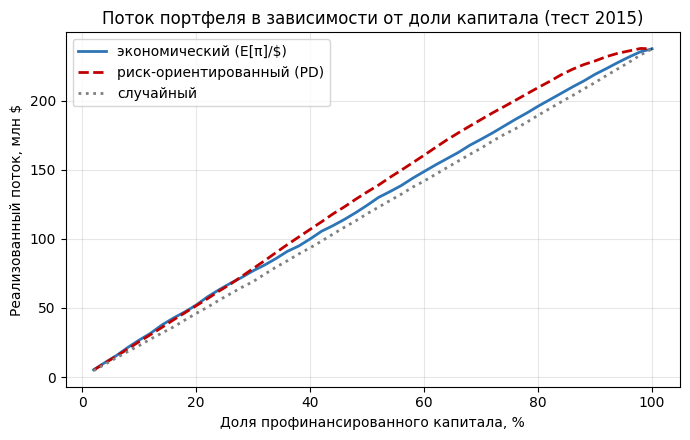

In [26]:
# Рис. 3.3 — реализованный поток портфеля от доли капитала (тест 2015)
grid = np.linspace(0.02, 1.0, 50)
fig, ax = plt.subplots(figsize=(7, 4.5))
styles = {'profit':   ('#2E75B6','-', 'экономический (E[π]/$)'),
          'risk(PD)': ('#C00000','--','риск-ориентированный (PD)'),
          'random':   ('gray',   ':', 'случайный')}
for k,(c,ls,lab) in styles.items():
    ax.plot(grid*100, [portfolio_flow(orders[k], L, net, f) for f in grid], ls, color=c, lw=2, label=lab)
ax.set_xlabel('Доля профинансированного капитала, %'); ax.set_ylabel('Реализованный поток, млн $')
ax.set_title('Поток портфеля в зависимости от доли капитала (тест 2015)')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig('../reports/fig_3_3_h2_curve.png', dpi=150); plt.show()

In [27]:
# === ДИАГНОСТИКА (вне основного пайплайна, §3.4): устойчивость знака H2 к OOT-калибровочному дрейфу ===
# Изотонику переобучаем НА ТЕСТЕ 2015 (in-sample, диагностика) — снимает OOT-занижение PD (§3.2).
# Все массивы берём из словарей money/money_d, а не из глобальных L/r/... (на случай переопределения в других ячейках).
from scipy.stats import spearmanr

# 1) калибратор, обученный на тесте (намеренно нарушает OOT)
iso_test          = IsotonicRegression(out_of_bounds='clip').fit(pd36_gbm, y36_test)
pd36_gbm_cal_test = iso_test.transform(pd36_gbm)

# 2) денежная выборка с тест-калиброванной PD (mask зависит от зрелости, не от PD → совпадает с основной)
money_d = money_slice(surv_test, pd36_gbm_cal_test)
assert np.array_equal(money_d['mask'], money['mask'])

# локальные массивы из словарей (надёжно)
Lm, rm, nm, netm = money['L'], money['r'], money['n'], money['net']
yv               = money['yv']
pd_oot           = money['pd_cal']        # PD при OOT-калибровке (основной анализ)
pd_test          = money_d['pd_cal']      # PD при тест-калибровке (диагностика)

# 3) сверка: устранён ли дрейф уровня PD
print(f"ср.PD: OOT-калибр. {pd_oot.mean()*100:5.1f}% | тест-калибр. {pd_test.mean()*100:5.1f}% | "
      f"факт деф@36 {yv.mean()*100:5.1f}%")

# 4) профит-скоры на обеих калибровках (та же функция прибыли: LGD=0.50, δ=3%)
g, b        = pv_comp(Lm, rm, nm, lgd=0.50, disc=0.03)
profit_oot  = ((1-pd_oot)*g  + pd_oot*b)  / Lm
profit_test = ((1-pd_test)*g + pd_test*b) / Lm

# 5) ранговая устойчивость профит-скора к смене калибровки
rho = spearmanr(profit_oot, profit_test).correlation
print(f"ранговая корр. профит-скора (OOT vs тест-калибровка): {rho:.4f}")

# 6) выигрыш profit−PD при бюджете 30% + бутстрэп-ДИ (2000 реплик), на обеих калибровках
f = 0.30
for tag, ps, pd_ in [("OOT-калибр. (основной)", profit_oot,  pd_oot),
                     ("тест-калибр. (диагн.)", profit_test, pd_test)]:
    pf = portfolio_flow(np.argsort(-ps),  Lm, netm, f)
    rf = portfolio_flow(np.argsort(pd_),  Lm, netm, f)   # риск-отбор: меньшая PD первой
    ds = bootstrap_gain(ps, -pd_, Lm, netm, f, B=2000)
    print(f"{tag}: profit {pf:+.1f} | PD {rf:+.1f} | выигрыш {pf-rf:+.1f} млн "
          f"| 95%ДИ [{np.percentile(ds,2.5):+.1f}; {np.percentile(ds,97.5):+.1f}]")

ср.PD: OOT-калибр.  12.7% | тест-калибр.  15.0% | факт деф@36  14.9%
ранговая корр. профит-скора (OOT vs тест-калибровка): 0.9613
OOT-калибр. (основной): profit +76.9 | PD +78.5 | выигрыш -1.6 млн | 95%ДИ [-4.2; +1.0]
тест-калибр. (диагн.): profit +80.7 | PD +78.6 | выигрыш +2.1 млн | 95%ДИ [-0.4; +4.6]


In [28]:
for f in [0.10, 0.30, 0.50]:
    print(f"--- бюджет {int(f*100)}% ---")
    for tag, ps, pd_ in [("OOT-калибр", profit_oot, pd_oot), ("тест-калибр", profit_test, pd_test)]:
        pf = portfolio_flow(np.argsort(-ps), Lm, netm, f)
        rf = portfolio_flow(np.argsort(pd_), Lm, netm, f)
        ds = bootstrap_gain(ps, -pd_, Lm, netm, f, B=2000)
        print(f"  {tag:>11}: profit {pf:+.1f} | PD {rf:+.1f} | выигрыш {pf-rf:+.1f} млн "
              f"| 95%ДИ [{np.percentile(ds,2.5):+.1f}; {np.percentile(ds,97.5):+.1f}]")

--- бюджет 10% ---
   OOT-калибр: profit +26.7 | PD +25.6 | выигрыш +1.1 млн | 95%ДИ [-0.3; +2.9]
  тест-калибр: profit +28.7 | PD +25.4 | выигрыш +3.2 млн | 95%ДИ [+1.6; +4.8]
--- бюджет 30% ---
   OOT-калибр: profit +76.9 | PD +78.5 | выигрыш -1.6 млн | 95%ДИ [-4.2; +1.0]
  тест-калибр: profit +80.7 | PD +78.6 | выигрыш +2.1 млн | 95%ДИ [-0.4; +4.6]
--- бюджет 50% ---
   OOT-калибр: profit +124.3 | PD +133.9 | выигрыш -9.6 млн | 95%ДИ [-12.4; -6.7]
  тест-калибр: profit +130.2 | PD +134.0 | выигрыш -3.9 млн | 95%ДИ [-6.5; -1.2]


### 5.4 Профиль отобранного портфеля @30 % (вход Табл. 3.5 / §3.4)
Что именно отбирает каждый критерий. Ожидаемо: profit — выше ставка, PD и дефолтность, но и
дисперсия потока; risk — низкие PD/дефолт, но и низкая ставка.

In [29]:
f = 0.30
profile_orders = {'profit (E[π]/$)': np.argsort(-profit_score),
                  'risk (PD)'       : np.argsort(risk_score),
                  'random'          : np.random.default_rng(SEED).permutation(len(L))}
hdr = (f"{'критерий':>16} | {'n':>6} | {'ставка':>7} | {'сумма':>7} | {'ср.PD':>6} | "
       f"{'дефолт@36':>9} | {'net/кред':>9} | {'σ(net)':>8}")
print(hdr); print('-'*len(hdr))
for k, o in profile_orders.items():
    s = portfolio_select(o, L, f)
    print(f"{k:>16} | {len(s):>6} | {r[s].mean()*100:>6.1f}% | ${L[s].mean():>6.0f} | "
          f"{pd_money[s].mean()*100:>5.1f}% | {yv_money[s].mean()*100:>8.1f}% | "
          f"${net[s].mean():>+8.0f} | ${net[s].std():>7.0f}")
    

        критерий |      n |  ставка |   сумма |  ср.PD | дефолт@36 |  net/кред |   σ(net)
-----------------------------------------------------------------------------------------
 profit (E[π]/$) |  83185 |   14.3% | $ 13071 |  14.3% |     18.8% | $    +924 | $   4237
       risk (PD) |  71654 |    7.3% | $ 15174 |   4.6% |      5.4% | $   +1096 | $   2171
          random |  84925 |   11.3% | $ 12803 |  12.8% |     15.0% | $    +813 | $   3364


In [30]:
import numpy as np
RES_OK = ['Fully Paid','Charged Off','Default',
          'Does not meet the credit policy. Status:Fully Paid',
          'Does not meet the credit policy. Status:Charged Off']
m    = (surv_test['mob'].values >= surv_test['term_months'].values) & surv_test['loan_status'].isin(RES_OK).values
L_   = surv_test['loan_amnt'].values[m].astype(float)
net_ = surv_test['total_pymnt'].values[m] - L_
pd_  = pd36_gbm_cal[m]
order = np.argsort(pd_)                                  # риск-отбор: низкая PD первой
sel   = order[np.cumsum(L_[order]) <= 0.30 * L_.sum()]   # бюджет 30%
print(f'risk(PD) @30%: n = {len(sel)} | '
      f'net/кред = ${net_[sel].mean():+.1f} | '
      f'капитал = {L_[sel].sum()/1e6:.1f} млн')

risk(PD) @30%: n = 71654 | net/кред = $+1095.6 | капитал = 1087.3 млн


### 5.5 Устойчивость выигрыша H2 к LGD и моменту дефолта m (бюджет 30 %)

In [31]:
f = 0.30
base_risk = portfolio_flow(orders['risk(PD)'], L, net, f)
print(f'риск-поток (база, PD) @30% = {base_risk:.1f} млн\n--- устойчивость к LGD (m=15%) ---')
for lgd in LGD_GRID:
    gg, bb = pv_comp(L, r, n_term, lgd=lgd, disc=0.03, dmf=0.15)
    sp = ((1-pd_money)*gg + pd_money*bb) / L
    pf = portfolio_flow(np.argsort(-sp), L, net, f)
    print(f'  LGD={lgd}: profit={pf:.1f}  Δ={pf-base_risk:+.1f} млн')
print('--- устойчивость к моменту дефолта m (LGD=0.50) ---')
for dmf in M_GRID:
    gg, bb = pv_comp(L, r, n_term, lgd=0.50, disc=0.03, dmf=dmf)
    sp = ((1-pd_money)*gg + pd_money*bb) / L
    pf = portfolio_flow(np.argsort(-sp), L, net, f)
    print(f'  m={int(dmf*100)}% срока: profit={pf:.1f}  Δ={pf-base_risk:+.1f} млн')

риск-поток (база, PD) @30% = 78.5 млн
--- устойчивость к LGD (m=15%) ---
  LGD=0.45: profit=74.6  Δ=-4.0 млн
  LGD=0.5: profit=76.9  Δ=-1.6 млн
  LGD=0.55: profit=78.6  Δ=+0.1 млн
--- устойчивость к моменту дефолта m (LGD=0.50) ---
  m=10% срока: profit=78.7  Δ=+0.2 млн
  m=15% срока: profit=76.9  Δ=-1.6 млн
  m=25% срока: profit=72.5  Δ=-6.0 млн
  m=40% срока: profit=67.3  Δ=-11.2 млн


### 5.6 Устойчивость ОТБОРА H2 к ставке дисконтирования δ (бюджет 30%).
profit_score считается при δ=3%. Проверяем, что РАНЖИРОВАНИЕ заявок (а значит состав портфеля и выигрыш) почти не зависит от δ: δ в основном масштабирует прибыль, не меняя порядок.

In [32]:
from scipy.stats import spearmanr
f = 0.30
g0, b0 = pv_comp(L, r, n_term, lgd=0.50, disc=0.03)
base_score = ((1 - pd_money) * g0 + pd_money * b0) / L          # базовый критерий (δ=3%)
order_risk = np.argsort(risk_score)
rf = portfolio_flow(order_risk, L, net, f)         # поток risk(PD)-портфеля
print("  δ  | Spearman с δ=3% | выигрыш над risk(PD), млн $")
for disc in [0.00, 0.03, 0.06, 0.09, 0.12]:
    g, b = pv_comp(L, r, n_term, lgd=0.50, disc=disc)
    sc = ((1 - pd_money) * g + pd_money * b) / L
    rho = spearmanr(sc, base_score).correlation                 # ранговая корреляция с базой
    pf = portfolio_flow(np.argsort(-sc), L, net, f)
    print(f"{disc*100:>3.0f}% | {rho:>14.4f} | {pf - rf:+.1f}")

  δ  | Spearman с δ=3% | выигрыш над risk(PD), млн $
  0% |         0.9981 | -0.9
  3% |         1.0000 | -1.6


/var/folders/g3/xg88266s6cq_v9k42skd_99c0000gn/T/ipykernel_89243/1655897855.py:34: RuntimeWarning: invalid value encountered in divide
  x = np.asarray(x, float)*np.ones_like(k); return np.where(x>0, (1-(1+x)**(-k))/x, k)


  6% |         0.9982 | -2.7
  9% |         0.9934 | -4.0
 12% |         0.9856 | -4.4


In [33]:
# Капитал под бюджет и порог материальности 1% капитала (тест 2015)
for f in [0.10, 0.30, 0.50]:
    cap = f * tot
    print(f"{int(f*100):>3}%: капитал {cap/1e6:7.0f} млн $ | "
          f"порог материальности 1% = ±{0.01*cap/1e6:.1f} млн $")

 10%: капитал     362 млн $ | порог материальности 1% = ±3.6 млн $
 30%: капитал    1087 млн $ | порог материальности 1% = ±10.9 млн $
 50%: капитал    1812 млн $ | порог материальности 1% = ±18.1 млн $


In [34]:
# === Усреднение «случайного» базового уровня по многим перестановкам (для Табл. 3.4) ===
# Базлайн random сейчас — одна перестановка. Усредняем по N_PERM реализациям,
# приводим среднее и разброс вместо единичного draw.
N_PERM = 500
rng_mc = np.random.default_rng(SEED)
budgets = BUDGETS
samples = {f: np.empty(N_PERM) for f in budgets}
for j in range(N_PERM):
    perm = rng_mc.permutation(len(L))
    for f in budgets:
        samples[f][j] = portfolio_flow(perm, L, net, f)
print(f"{'бюджет':>7} | {'среднее':>9} | {'ст.откл.':>8} | {'2.5%':>8} | {'97.5%':>8}   (млн $, N={N_PERM})")
for f in budgets:
    s = samples[f]; lo, hi = np.percentile(s, [2.5, 97.5])
    print(f"{int(f*100):>6}% | {s.mean():>9.1f} | {s.std():>8.2f} | {lo:>8.1f} | {hi:>8.1f}")
print("--- для сравнения, одиночная перестановка (как в тексте сейчас):")
for f in budgets:
    print(f"  @ {int(f*100)}%: {portfolio_flow(orders['random'], L, net, f):.1f} млн")

 бюджет |   среднее | ст.откл. |     2.5% |    97.5%   (млн $, N=500)
    10% |      23.8 |     0.52 |     22.8 |     24.8
    30% |      71.2 |     0.81 |     69.6 |     72.8
    50% |     118.8 |     0.90 |    116.9 |    120.5
--- для сравнения, одиночная перестановка (как в тексте сейчас):
  @ 10%: 22.7 млн
  @ 30%: 69.1 млн
  @ 50%: 118.2 млн


In [35]:
m = money['mask']; sub = surv_test[m]
print('сумма: медиана', sub['loan_amnt'].median(), '| среднее', round(sub['loan_amnt'].mean()),
      '| p10–p90', sub['loan_amnt'].quantile([.1,.9]).values)
print('доход: медиана', sub['annual_inc'].median(), '| p10–p90', sub['annual_inc'].quantile([.1,.9]).values)
print('ставка: min/медиана/max', sub['int_rate'].min(), sub['int_rate'].median(), sub['int_rate'].max())
print('DTI медиана', sub['dti'].median(), '| FICO low медиана', sub['fico_range_low'].median(),
      sub['fico_range_low'].quantile([.1,.9]).values)
print((sub['grade'].value_counts(normalize=True).sort_index()*100).round(1))
yv = ((sub['event'].values==1) & (sub['duration'].values<=36)).astype(int)
print((pd.Series(yv, index=sub.index).groupby(sub['grade']).mean()*100).round(1))  # дефолт@36 по грейду

сумма: медиана 10000.0 | среднее 12806 | p10–p90 [ 4500. 25000.]
доход: медиана 62000.0 | p10–p90 [ 32000. 125000.]
ставка: min/медиана/max 5.32 11.22 28.99
DTI медиана 17.87 | FICO low медиана 685.0 [660. 735.]
grade
A    24.8
B    32.4
C    27.4
D    11.6
E     3.3
F     0.5
G     0.1
Name: proportion, dtype: float64
grade
A     5.4
B    11.9
C    19.4
D    26.2
E    32.8
F    42.4
G    46.1
dtype: float64


## Блок 6. Проверки на тех же объектах (Табл. 3.3, 3.5, 3.6, 3.8; кластерный вывод)
Все ячейки переиспользуют канонические `money`/`L,r,n_term,net,pd_money`, `profit_score`,
`risk_score`, `pv_comp` (Блок 5) и `pd36_*` (Блоки 3–4) — без переобучения моделей и без
переопределения срезов. Проверки с переобучением (репликация 2014 §3.5, PD без внутр. скоринга,
60-мес сплит, перебор гиперпараметров) вынесены в Блок 7.

### 6.1 H3 (§3.6): надёжность параметрической функции прибыли (Табл. 3.8)
Параметрический вердикт «пляшет» от ненаблюдаемых LGD и m, фактический денежный поток того же
портфеля — устойчив.

In [36]:
MS = [0.10, 0.15, 0.25, 0.40, 0.60]
print('(A) ПАРАМЕТРИЧЕСКАЯ оценка прибыли одобренного портфеля, млн $:')
print(f"{'LGD/m':>6} | " + ' | '.join(f'm={d:>4}' for d in MS))
for lgd in LGD_GRID:
    row = []
    for dmf in MS:
        g, b = pv_comp(L, r, n_term, lgd=lgd, disc=0.03, dmf=dmf)
        epi = (1-pd_money)*g + pd_money*b
        row.append(f'{epi[epi>=0].sum()/1e6:>6.1f}')
    print(f'{lgd:>6} | ' + ' | '.join(row))
print('\n(B) ФАКТИЧЕСКИЙ денежный поток того же одобренного портфеля, млн $ (доля одобренных):')
print(f"{'LGD/m':>6} | " + ' | '.join(f'm={d:>4}' for d in MS))
for lgd in LGD_GRID:
    row = []
    for dmf in MS:
        g, b = pv_comp(L, r, n_term, lgd=lgd, disc=0.03, dmf=dmf)
        appr = ((1-pd_money)*g + pd_money*b) >= 0
        row.append(f'{net[appr].sum()/1e6:>6.1f} ({appr.mean()*100:>3.0f}%)')
    print(f'{lgd:>6} | ' + ' | '.join(row))

(A) ПАРАМЕТРИЧЕСКАЯ оценка прибыли одобренного портфеля, млн $:
 LGD/m | m= 0.1 | m=0.15 | m=0.25 | m= 0.4 | m= 0.6
  0.45 |  222.9 |  239.4 |  271.9 |  311.2 |  363.3
   0.5 |  203.3 |  220.6 |  255.3 |  297.4 |  353.7
  0.55 |  184.1 |  202.2 |  238.7 |  283.6 |  344.1

(B) ФАКТИЧЕСКИЙ денежный поток того же одобренного портфеля, млн $ (доля одобренных):
 LGD/m | m= 0.1 | m=0.15 | m=0.25 | m= 0.4 | m= 0.6
  0.45 |  237.3 ( 99%) |  237.2 (100%) |  237.5 (100%) |  237.4 (100%) |  237.4 (100%)
   0.5 |  236.7 ( 98%) |  237.2 ( 99%) |  237.3 (100%) |  237.4 (100%) |  237.4 (100%)
  0.55 |  235.9 ( 97%) |  236.6 ( 98%) |  237.2 ( 99%) |  237.5 (100%) |  237.4 (100%)


### 6.1a Устойчивость ранжирования: Спирмен/Жаккар по решётке LGD×m 
Ранговая корреляция профит-скора к базовому варианту и пересечение топ-портфелей @30% — вход для §3.6

In [37]:
from scipy.stats import spearmanr
def jaccard(a, b): sa, sb = set(a.tolist()), set(b.tolist()); return len(sa & sb)/len(sa | sb)
def top(score, f): return portfolio_select(np.argsort(-score), L, f)
f = 0.30
print(f"Жаккар(профит-топ, риск-топ) @30%: {jaccard(top(profit_score,f), top(risk_score,f)):.2f}")
print(f"Спирмен(профит-скор, net):         {spearmanr(profit_score, net).correlation:.2f}")
base = profit_score; base_top = top(base, f)
print("Спирмен профит-скора к базовому и Жаккар топ-портфеля по сетке (LGD×m):")
for lgd in LGD_GRID:
    for dmf in M_GRID:
        g, b = pv_comp(L, r, n_term, lgd=lgd, disc=0.03, dmf=dmf)
        s = ((1-pd_money)*g + pd_money*b)/L
        print(f"  LGD={lgd} m={int(dmf*100)}%: Спирмен={spearmanr(s, base).correlation:.3f}  "
              f"Жаккар={jaccard(top(s,f), base_top):.2f}")

Жаккар(профит-топ, риск-топ) @30%: 0.22
Спирмен(профит-скор, net):         0.09
Спирмен профит-скора к базовому и Жаккар топ-портфеля по сетке (LGD×m):
  LGD=0.45 m=10%: Спирмен=1.000  Жаккар=0.99
  LGD=0.45 m=15%: Спирмен=0.993  Жаккар=0.93
  LGD=0.45 m=25%: Спирмен=0.950  Жаккар=0.81
  LGD=0.45 m=40%: Спирмен=0.877  Жаккар=0.67
  LGD=0.5 m=10%: Спирмен=0.991  Жаккар=0.92
  LGD=0.5 m=15%: Спирмен=1.000  Жаккар=1.00
  LGD=0.5 m=25%: Спирмен=0.974  Жаккар=0.87
  LGD=0.5 m=40%: Спирмен=0.902  Жаккар=0.71
  LGD=0.55 m=10%: Спирмен=0.966  Жаккар=0.86
  LGD=0.55 m=15%: Спирмен=0.992  Жаккар=0.92
  LGD=0.55 m=25%: Спирмен=0.990  Жаккар=0.93
  LGD=0.55 m=40%: Спирмен=0.925  Жаккар=0.75


### 6.1b ДИ выигрыша по решётке LGD×m (Табл. в §3.6)
Проверка устойчивости знака выигрыша по всем 12 комбинациям (LGD ∈ {0,45; 0,50; 0,55} × m ∈ {10; 15; 25; 40 %}). На тесте 2015 выигрыш над risk(PD) не является значимо положительным ни в одной из них, а при больших m становится значимо отрицательным — что согласуется с основным выводом о контингентности H2.

In [38]:
f = 0.30
def gain_ci(score, B=B_AUX, seed=SEED):               # score «больше = лучше»
    pf = portfolio_flow(np.argsort(-score), L, net, f)
    rf = portfolio_flow(np.argsort(risk_score), L, net, f)
    ds = bootstrap_gain(score, -risk_score, L, net, f, B=B, seed=seed)
    lo, hi = np.percentile(ds, [2.5, 97.5]); return pf-rf, lo, hi
print("Выигрыш профит над risk(PD) @30% по решётке LGD×m (95% ДИ):")
allpos = True
for lgd in LGD_GRID:
    for dmf in M_GRID:
        g, b = pv_comp(L, r, n_term, lgd=lgd, disc=0.03, dmf=dmf)
        d, lo, hi = gain_ci(((1-pd_money)*g + pd_money*b)/L)
        allpos &= lo > 0
        print(f"  LGD={lgd} m={int(dmf*100):>2}%: Δ={d:+.1f} [{lo:+.1f}; {hi:+.1f}] {'+' if lo>0 else '0!'}")
print("Все 12 ячеек строго положительны:" , allpos)

Выигрыш профит над risk(PD) @30% по решётке LGD×m (95% ДИ):
  LGD=0.45 m=10%: Δ=-1.6 [-4.4; +1.3] 0!
  LGD=0.45 m=15%: Δ=-4.0 [-6.8; -1.0] 0!
  LGD=0.45 m=25%: Δ=-7.3 [-10.4; -4.6] 0!
  LGD=0.45 m=40%: Δ=-12.5 [-15.5; -9.6] 0!
  LGD=0.5 m=10%: Δ=+0.2 [-2.5; +3.0] 0!
  LGD=0.5 m=15%: Δ=-1.6 [-4.5; +1.2] 0!
  LGD=0.5 m=25%: Δ=-6.0 [-8.9; -3.2] 0!
  LGD=0.5 m=40%: Δ=-11.2 [-14.4; -8.3] 0!
  LGD=0.55 m=10%: Δ=+1.7 [-1.1; +4.4] 0!
  LGD=0.55 m=15%: Δ=+0.1 [-2.6; +2.9] 0!
  LGD=0.55 m=25%: Δ=-4.2 [-7.1; -1.5] 0!
  LGD=0.55 m=40%: Δ=-9.8 [-12.8; -6.8] 0!
Все 12 ячеек строго положительны: False


### 6.2 Декомпозиция S0/S1/S2 (Табл. 3.3)
S0 — логрег + порог по F1; S1 — бустинг + порог по F1; S2 — бустинг + порог по прибыли (одобрить всех).

In [39]:
# 6.2 Декомпозиция S0/S1/S2 (Табл. 3.3): корректная версия.
# Здесь же определяются helper'ы, нужные для всего Блока 6.2:
# pd36_lr_valid (LR-PD@36 на валидации 2014), mat_mask, best_f1_thr.
from sklearn.metrics import f1_score

mat_mask = money['mask']                       # дозревшая денежная маска теста 2015

# LR-hazard PD@36 на валидации 2014 (GBM-версия pd36_gbm_valid уже есть из Блока 4)
pd36_lr_valid = survival_pd36(
    lambda X: lr_hazard.predict_proba(sc_hazard.transform(imp_hazard.transform(X)))[:, 1],
    surv_valid)

def best_f1_thr(y, p):
    """F1-оптимальный порог по сетке вероятностей [0.02; 0.95]."""
    grid = np.linspace(0.02, 0.95, 200)
    return grid[int(np.argmax([f1_score(y, (p >= t).astype(int)) for t in grid]))]

pd36_gbm_cal_valid = iso_calibrator.transform(pd36_gbm_valid)     # калиброванная валидация GBM
thr_lr  = best_f1_thr(y36_valid, pd36_lr_valid)                   # LR: некалибр. шкала
thr_gbm = best_f1_thr(y36_valid, pd36_gbm_cal_valid)              # GBM: КАЛИБР. шкала

S0 = net[pd36_lr[mat_mask]      < thr_lr ].sum()/1e6              # логрег + F1
S1 = net[pd36_gbm_cal[mat_mask] < thr_gbm].sum()/1e6              # бустинг + F1 на калибр. шкале
S2 = net.sum()/1e6                                                # бустинг + порог по прибыли = одобрить всех

appr_lr  = (pd36_lr[mat_mask]      < thr_lr ).mean()
appr_gbm = (pd36_gbm_cal[mat_mask] < thr_gbm).mean()

print(f'S0 (логрег + F1):              {S0:>+8.2f} млн')
print(f'S1 (бустинг + F1, калибр.):    {S1:>+8.2f} млн   Δ_model     = {S1-S0:+.2f}')
print(f'S2 (бустинг + порог-прибыль):  {S2:>+8.2f} млн   Δ_threshold = {S2-S1:+.2f}')
print(f'Доля одобрения: LR={appr_lr*100:.0f}%  GBM={appr_gbm*100:.0f}%')

/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


S0 (логрег + F1):               +199.85 млн
S1 (бустинг + F1, калибр.):     +202.89 млн   Δ_model     = +3.04
S2 (бустинг + порог-прибыль):   +237.43 млн   Δ_threshold = +34.54
Доля одобрения: LR=74%  GBM=74%


### 6.2a Вклад модели (GBM vs LR) в профит-портфель

Сравнение профит-портфелей на GBM-PD и калиброванной LR-PD. 

In [40]:
# 6.2a Вклад модели (GBM vs LR) в профит-портфель.
iso_lr = IsotonicRegression(out_of_bounds='clip').fit(pd36_lr_valid, y36_valid)
pd_lr_money = iso_lr.transform(pd36_lr)[money['mask']]
g, b = pv_comp(L, r, n_term, lgd=0.50, disc=0.03)
profit_lr = ((1-pd_lr_money)*g + pd_lr_money*b) / L          # профит-скор на LR-PD

def jaccard(a, b): sa, sb = set(a.tolist()), set(b.tolist()); return len(sa & sb)/len(sa | sb)
def sel(score, f): return portfolio_select(np.argsort(-score), L, f)

rng = np.random.default_rng(SEED)
for f in [0.10, 0.30]:
    g_gbm = portfolio_flow(np.argsort(-profit_score), L, net, f)
    g_lr  = portfolio_flow(np.argsort(-profit_lr),    L, net, f)
    ds = bootstrap_gain(profit_score, profit_lr, L, net, f, B=B_MAIN, rng=rng)
    lo, hi = np.percentile(ds, [2.5, 97.5])
    print(f'{int(f*100)}%: вклад модели (GBM−LR) = {g_gbm-g_lr:+.1f} млн  95%ДИ[{lo:+.1f}; {hi:+.1f}]  '
          f'Жаккар(GBM,LR)={jaccard(sel(profit_score,f), sel(profit_lr,f)):.2f}')
    

10%: вклад модели (GBM−LR) = +2.6 млн  95%ДИ[+1.3; +3.9]  Жаккар(GBM,LR)=0.49
30%: вклад модели (GBM−LR) = +4.0 млн  95%ДИ[+2.3; +5.5]  Жаккар(GBM,LR)=0.63


In [41]:
# Подбор F1-порога ДЛЯ КАЖДОЙ модели на ЕЁ ЖЕ шкале (LR — некалиброванная, GBM — калиброванная).
pd36_gbm_cal_valid = iso_calibrator.transform(pd36_gbm_valid)     # калиброванная валидация GBM
thr_lr  = best_f1_thr(y36_valid, pd36_lr_valid)                   # LR: некалибр. шкала (как в S0/тесте)
thr_gbm = best_f1_thr(y36_valid, pd36_gbm_cal_valid)              # GBM: КАЛИБР. шкала (как в S1/тесте)
S0 = net[pd36_lr[mat_mask]      < thr_lr ].sum()/1e6
S1 = net[pd36_gbm_cal[mat_mask] < thr_gbm].sum()/1e6
S2 = net.sum()/1e6
appr_lr  = (pd36_lr[mat_mask]      < thr_lr ).mean()
appr_gbm = (pd36_gbm_cal[mat_mask] < thr_gbm).mean()
print(f'S0 {S0:+.2f} | S1 {S1:+.2f} (Δ_model {S1-S0:+.2f}) | S2 {S2:+.2f} (Δ_thr {S2-S1:+.2f})')
print(f'Доля одобрения: LR={appr_lr*100:.0f}%  GBM={appr_gbm*100:.0f}%')

S0 +199.85 | S1 +202.89 (Δ_model +3.04) | S2 +237.43 (Δ_thr +34.54)
Доля одобрения: LR=74%  GBM=74%


In [42]:
# §3.3: глобальный порог по прибыли, подобранный на ВАЛИДАЦИИ, одобряет ~100% ТЕСТА.
# Порог τ на E[π]/$: одобряем заявки с profit_score >= τ. Максимизируем суммарный
# реализованный поток одобренных на валидации 2014, затем применяем найденный τ к тесту 2015.

# --- валидация 2014: своя денежная выборка + калиброванная PD 2014 ---
mob_v = surv_valid['mob'].values; term_v = surv_valid['term_months'].values
msk_v = (mob_v >= term_v) & surv_valid['loan_status'].isin(RES_OK).values
Lv  = surv_valid['loan_amnt'].values[msk_v].astype(float)
rv  = surv_valid['int_rate'].values[msk_v] / 100
nv  = surv_valid['term_months'].values[msk_v].astype(float)
netv = surv_valid['total_pymnt'].values[msk_v] - Lv  # total_pymnt уже включает recoveries
pdv  = iso_calibrator.transform(pd36_gbm_valid)[msk_v]
gv, bv = pv_comp(Lv, rv, nv, lgd=0.50, disc=0.03)
score_v = ((1 - pdv)*gv + pdv*bv) / Lv          # E[π]/$ на валидации

# тест 2015 (канонические объекты Блока 5)
g, b = pv_comp(L, r, n_term, lgd=0.50, disc=0.03)
score_t = ((1 - pd_money)*g + pd_money*b) / L   # E[π]/$ на тесте

# подбор глобального порога τ на валидации: максимум суммарного потока одобренных
grid = np.quantile(score_v, np.linspace(0, 1, 201))
flows = [netv[score_v >= tau].sum() for tau in grid]
tau_star = grid[int(np.argmax(flows))]

appr_v = (score_v >= tau_star).mean()
appr_t = (score_t >= tau_star).mean()
print(f'Глобальный порог по прибыли (δ=3%, LGD=0.50), подобран на валидации 2014:')
print(f'  τ* = {tau_star:+.4f}  (E[π]/$)')
print(f'  одобрено на валидации 2014: {appr_v*100:.1f}%')
print(f'  одобрено на тесте 2015:     {appr_t*100:.1f}%')

Глобальный порог по прибыли (δ=3%, LGD=0.50), подобран на валидации 2014:
  τ* = -0.1453  (E[π]/$)
  одобрено на валидации 2014: 100.0%
  одобрено на тесте 2015:     100.0%


### 6.3 Источник выигрыша H2 (Табл. 3.6)
Само по себе добавление ставки выигрыша над risk(PD) не даёт: правила «ставка», «rate×(1−PD)» и «доход/$» дают значимо меньший поток. Не уступает risk(PD) только полная форма прибыли.
Плюс разложение: какая доля выигрыша — от крена к высокому APR, какая — от отбора внутри APR-уровней.

In [43]:
g, b = pv_comp(L, r, n_term, lgd=0.50, disc=0.03)
i_m = r/12.; A_m = np.where(i_m>0, L*i_m/(1-(1+i_m)**(-n_term)), L/n_term)
exp_int_per_dollar = ((A_m*n_term - L)/L) * (1-pd_money)               # ожидаемый процентный доход на $
g_nr, b_nr = pv_comp(L, np.full_like(r, r.mean()), n_term, lgd=0.50, disc=0.03)  # та же форма, ставка=средней
# Единое соглашение о знаке: все скоры «больше = лучше», отбор = argsort(-score).
abl = {
    'profit/$ (база)':   ((1-pd_money)*g + pd_money*b)/L,
    'risk(PD)':          -pd_money,
    'rate':               r,
    'rate×(1−PD)':         r*(1-pd_money),
    'E[%дохода]/$':       exp_int_per_dollar,
    'profit_без_ставки':  ((1-pd_money)*g_nr + pd_money*b_nr)/L,
}
abl_orders = {k: np.argsort(-v) for k, v in abl.items()}
abl_orders['random'] = np.random.default_rng(SEED).permutation(len(L))
print(f"{'бюджет':>7} | " + ' | '.join(f'{k:>16}' for k in abl_orders))
for f in [0.10, 0.30]:
    print(f'{int(f*100):>6}% | ' + ' | '.join(f'{portfolio_flow(o, L, net, f):>16.1f}' for o in abl_orders.values()))

# Разложение выигрыша: крен по APR vs отбор сверх APR-профиля (бюджет 30%)
f = 0.30
prof_idx = portfolio_select(np.argsort(-profit_score), L, f); risk_idx = portfolio_select(np.argsort(risk_score), L, f)
prof_flow = net[prof_idx].sum()/1e6; risk_flow = net[risk_idx].sum()/1e6
NB = 20
edges = np.quantile(r, np.linspace(0, 1, NB+1)); edges[0] = -np.inf; edges[-1] = np.inf
bin_all = np.clip(np.digitize(r, edges[1:-1]), 0, NB-1); bin_tg = bin_all[prof_idx]
def apr_matched_random(B=300):
    vals = []
    for seed in range(B):
        rr = np.random.default_rng(seed); sel = []
        for bb in range(NB):
            tgtL = L[prof_idx[bin_tg == bb]].sum()
            if tgtL <= 0: continue
            pool = rr.permutation(np.where(bin_all == bb)[0]); c = np.cumsum(L[pool]); sel.append(pool[c <= tgtL])
        idx = np.concatenate(sel) if sel else np.array([], int); vals.append(net[idx].sum()/1e6)
    return float(np.mean(vals))
apr_rand = apr_matched_random()
gain_total = prof_flow - risk_flow; gain_apr = apr_rand - risk_flow; gain_beyond = prof_flow - apr_rand
print(f'\nРазложение выигрыша profit − risk(PD) @30% (всего {gain_total:+.1f} млн):')
print(f'  крен по APR (APR-matched random): {gain_apr:+.1f} млн ({gain_apr/gain_total*100:.0f}%)')
print(f'  отбор сверх APR-профиля:          {gain_beyond:+.1f} млн ({gain_beyond/gain_total*100:.0f}%)')

 бюджет |  profit/$ (база) |         risk(PD) |             rate |      rate×(1−PD) |     E[%дохода]/$ | profit_без_ставки |           random
    10% |             26.7 |             25.6 |             11.9 |             18.5 |             18.0 |             25.4 |             22.7
    30% |             76.9 |             78.5 |             57.1 |             62.0 |             61.4 |             78.6 |             69.1

Разложение выигрыша profit − risk(PD) @30% (всего -1.6 млн):
  крен по APR (APR-matched random): -13.1 млн (797%)
  отбор сверх APR-профиля:          +11.5 млн (-697%)


### 6.3a Lowest-PD внутри APR-профиля (§3.4.2)
Контрольный отбор: внутри каждого APR-страта берём кредиты с минимальной PD. Должен почти точно воспроизвести профит-портфель (~77 млн), подтверждая, что выигрыш = скрининг по PD внутри APR-уровней

In [44]:
f = 0.30
prof_idx = portfolio_select(np.argsort(-profit_score), L, f)
NB = 20; edges = np.quantile(r, np.linspace(0, 1, NB+1)); edges[0] = -np.inf; edges[-1] = np.inf
bin_all = np.clip(np.digitize(r, edges[1:-1]), 0, NB-1); bin_tg = bin_all[prof_idx]
sel = []
for bb in range(NB):
    tgtL = L[prof_idx[bin_tg == bb]].sum()
    if tgtL <= 0: continue
    pool = np.where(bin_all == bb)[0]; pool = pool[np.argsort(pd_money[pool])]   # минимальная PD внутри страта
    sel.append(pool[np.cumsum(L[pool]) <= tgtL])
idx = np.concatenate(sel)
print(f"lowest-PD внутри APR-профиля: {net[idx].sum()/1e6:.1f} млн (профит-портфель {net[prof_idx].sum()/1e6:.1f})")
for name, order in [('крупные первыми', np.argsort(-L)), ('мелкие первыми', np.argsort(L))]:
    print(f"  {name}: {portfolio_flow(order, L, net, f):.1f} млн")

lowest-PD внутри APR-профиля: 76.6 млн (профит-портфель 76.9)
  крупные первыми: 76.5 млн
  мелкие первыми: 70.1 млн


### 6.3b Ablation с доверительными интервалами (Табл. 3.6)
Те же правила, что в 6.3, но с бутстрэп-ДИ для разницы с risk(PD). Полная форма прибыли — единственное правило со значимым выигрышем

In [45]:
f = 0.30
def rule_ci(score, B=B_AUX, seed=SEED):               # score в соглашении «больше = лучше»
    pf = portfolio_flow(np.argsort(-score), L, net, f)
    rf = portfolio_flow(np.argsort(risk_score), L, net, f)
    ds = bootstrap_gain(score, -risk_score, L, net, f, B=B, seed=seed)
    lo, hi = np.percentile(ds, [2.5, 97.5]); return pf-rf, lo, hi
print("Выигрыш над risk(PD) @30% по правилам ablation (95% ДИ):")
for k, v in abl.items():
    if k == 'risk(PD)': continue
    d, lo, hi = rule_ci(v)
    print(f"  {k:>18}: Δ={d:+.1f} [{lo:+.1f}; {hi:+.1f}] {'значимо' if lo>0 else ('значимо хуже' if hi<0 else 'неотличимо')}")

Выигрыш над risk(PD) @30% по правилам ablation (95% ДИ):
     profit/$ (база): Δ=-1.6 [-4.5; +1.2] неотличимо
                rate: Δ=-21.4 [-24.5; -18.7] значимо хуже
         rate×(1−PD): Δ=-16.5 [-19.6; -13.6] значимо хуже
        E[%дохода]/$: Δ=-17.1 [-20.2; -14.2] значимо хуже
   profit_без_ставки: Δ=+0.1 [-0.1; +0.5] неотличимо


### 6.3c Разложение по APR-квинтилям (Табл. 3.6a / 3.6b)

In [46]:
# === 6.3a Разложение механизма H2 по APR-квинтилям (тест 2015, бюджет 30%, δ=3%) ===
# На платформе PD скоррелирована с APR (риск-ценообразование),
# поэтому отбор по низкой PD концентрируется в Q1–Q2 (низкая ставка → низкий поток),
# а профит-отбор — в Q4–Q5, где доход компенсирует риск.

NQ = 5
edges_apr = np.quantile(r, np.linspace(0, 1, NQ+1))
edges_apr[0] = -np.inf; edges_apr[-1] = np.inf
apr_bin = np.clip(np.digitize(r, edges_apr[1:-1]), 0, NQ-1)

f = 0.30
sel = {k: portfolio_select(orders[k], L, f) for k in ['profit', 'risk(PD)', 'random']}

# --- Таблица A: характеристики APR-квинтилей во всей дозревшей денежной выборке ---
print('Таблица A. Структура популяции по APR-квинтилям (дозревшая выборка теста 2015)')
print(f"{'квинт.':>7} | {'APR, %':>13} | {'n':>9} | {'ср.PD@36':>9} | "
      f"{'дефолт@36':>10} | {'ср. net/$, %':>13}")
print('-' * 85)
for q in range(NQ):
    m = (apr_bin == q)
    print(f"     Q{q+1} | {r[m].min()*100:5.1f}–{r[m].max()*100:>5.1f}  | "
          f"{m.sum():>9,} | {pd_money[m].mean()*100:>8.1f}% | "
          f"{yv_money[m].mean()*100:>9.1f}% | {(net[m]/L[m]).mean()*100:>+12.1f}%")

# --- Таблица B: аллокация капитала и реализованный поток при бюджете 30 % ---
print(f'\nТаблица B. Аллокация капитала и поток по APR-квинтилям, бюджет {int(f*100)} %')
print(f"{'квинт.':>7} | {'profit: %кап / поток':>22} | "
      f"{'risk(PD): %кап / поток':>24} | {'random: %кап / поток':>22}   (поток, млн $)")
print('-' * 110)
for q in range(NQ):
    cells = []
    for k in ['profit', 'risk(PD)', 'random']:
        s = sel[k]; ms = s[apr_bin[s] == q]
        cap_share = L[ms].sum() / L[s].sum() * 100
        flow_q    = net[ms].sum() / 1e6
        cells.append(f"{cap_share:>7.1f}% / {flow_q:>+7.1f}")
    print(f"     Q{q+1} | {cells[0]:>22} | {cells[1]:>24} | {cells[2]:>22}")
print('-' * 110)
sums = {k: net[sel[k]].sum()/1e6 for k in sel}
profit_total = f"100.0% / {sums['profit']:+5.1f}"
risk_total   = f"100.0% / {sums['risk(PD)']:+5.1f}"
random_total = f"100.0% / {sums['random']:+5.1f}"

print(
    f"   итого | {profit_total:>22} | "
    f"{risk_total:>24} | "
    f"{random_total:>22}"
)

Таблица A. Структура популяции по APR-квинтилям (дозревшая выборка теста 2015)
 квинт. |        APR, % |         n |  ср.PD@36 |  дефолт@36 |  ср. net/$, %
-------------------------------------------------------------------------------------
     Q1 |   5.3–  7.5  |    49,787 |      4.4% |       4.5% |         +6.6%
     Q2 |   7.9–  9.8  |    58,561 |      8.3% |       9.1% |         +7.0%
     Q3 |  10.0– 12.1  |    57,232 |     11.3% |      13.6% |         +7.5%
     Q4 |  12.3– 14.0  |    60,579 |     16.0% |      18.9% |         +6.7%
     Q5 |  14.3– 29.0  |    56,867 |     22.7% |      26.9% |         +5.1%

Таблица B. Аллокация капитала и поток по APR-квинтилям, бюджет 30 %
 квинт. |   profit: %кап / поток |   risk(PD): %кап / поток |   random: %кап / поток   (поток, млн $)
--------------------------------------------------------------------------------------------------------------
     Q1 |         0.0% /    +0.0 |          61.9% /   +45.8 |        19.7% /   +14.2
     Q2 |  

In [47]:
NQ = 5
print(f"{'винтаж':>6} | {'n':>8} | " + ' '.join(f'Q{q+1:>5}' for q in range(NQ)) +
      f" | {'Q5-Q1':>6} | {'деф@36 Q5':>9}")
print('-' * 86)
for yr in [2011, 2012, 2013, 2014, 2015]:
    s = surv[surv['issue_year'] == yr]
    mob = s['mob'].values; term = s['term_months'].values
    msk = (mob >= term) & s['loan_status'].isin(RES_OK).values
    Ly = s['loan_amnt'].values[msk].astype(float)
    ry = s['int_rate'].values[msk] / 100
    nety = s['total_pymnt'].values[msk] - Ly
    yvy = ((s['event'].values[msk] == 1) & (s['duration'].values[msk] <= H)).astype(int)
    e = np.quantile(ry, np.linspace(0, 1, NQ + 1)); e[0] = -np.inf; e[-1] = np.inf
    qb = np.clip(np.digitize(ry, e[1:-1]), 0, NQ - 1)
    fl = [(nety[qb == q] / Ly[qb == q]).mean() * 100 for q in range(NQ)]
    defq5 = yvy[qb == NQ - 1].mean() * 100
    print(f"{yr:>6} | {int(msk.sum()):>8,} | " + ' '.join(f'{x:+5.1f}' for x in fl) +
          f" | {fl[NQ-1]-fl[0]:+5.1f} | {defq5:>8.1f}%")
print("\nЧитать вместе с выигрышем H2 по винтажам (Табл. 3.7/3.7а): знак Q5-Q1 совпадает со знаком выигрыша.")

винтаж |        n | Q    1 Q    2 Q    3 Q    4 Q    5 |  Q5-Q1 | деф@36 Q5
--------------------------------------------------------------------------------------
  2011 |   21,721 |  +5.7  +8.4 +10.1 +11.4 +13.3 |  +7.5 |     23.5%
  2012 |   53,367 |  +6.2  +8.5 +10.9 +11.7 +15.9 |  +9.6 |     24.5%
  2013 |  134,804 |  +9.0 +11.5 +13.5 +15.0 +16.9 |  +7.9 |     24.1%
  2014 |  162,570 |  +7.3  +8.9  +9.8  +9.4  +9.7 |  +2.3 |     23.5%
  2015 |  283,026 |  +6.6  +7.0  +7.5  +6.7  +5.1 |  -1.5 |     26.9%

Читать вместе с выигрышем H2 по винтажам (Табл. 3.7/3.7а): знак Q5-Q1 совпадает со знаком выигрыша.


### 6.4 Риск-скорректированное портфельное сравнение (Табл. 3.5)
Корректный объект риска — распределение доходности портфеля на капитал (ROC), с разделением
диверсифицируемой (i.i.d.) и недиверсифицируемой (винтажной, кластерный бутстрэп по месяцу выдачи)
частей. Пер-loan VaR/ES приведены лишь как контраст (в портфеле диверсифицируются).

In [48]:
month_money = surv_test['issue_date'].dt.month.values[money['mask']]
ra_orders = {'profit': np.argsort(-profit_score), 'risk(PD)': np.argsort(risk_score)}
rng = np.random.default_rng(SEED)
groups_all = {mo: np.where(month_money == mo)[0] for mo in np.unique(month_money)}
B = 2000

def risk_block(sel):
    x = net[sel]; Ls = L[sel]; nn = len(x); cap = Ls.sum(); roc_pt = x.sum()/cap
    sd_loan = x.std(); var5_loan = np.percentile(x, 5); es5_loan = x[x <= var5_loan].mean()
    roc_iid = np.empty(B)
    for j in range(B):
        ix = rng.integers(0, nn, nn); roc_iid[j] = x[ix].sum()/Ls[ix].sum()
    sd_iid = roc_iid.std()
    in_sel = np.zeros(len(L), bool); in_sel[sel] = True       # булева маска вместо set-membership
    gsel = {mo: idx[in_sel[idx]] for mo, idx in groups_all.items()}
    gsel = {mo: v for mo, v in gsel.items() if len(v) > 0}; keys = list(gsel)
    roc_clu = np.empty(B)
    for j in range(B):
        pick = rng.choice(keys, size=len(keys), replace=True)
        ii = np.concatenate([gsel[mo] for mo in pick]); roc_clu[j] = net[ii].sum()/L[ii].sum()
    sd_clu = roc_clu.std(); var5_clu = np.percentile(roc_clu, 5); es5_clu = roc_clu[roc_clu <= var5_clu].mean()
    return dict(n=nn, sumM=x.sum()/1e6, roc=roc_pt*100, sd_loan=sd_loan,
                var5_loan=var5_loan, es5_loan=es5_loan, sd_iid=sd_iid*100, sd_clu=sd_clu*100,
                var5_clu=var5_clu*100, es5_clu=es5_clu*100, ratio=sd_clu/sd_iid, p_neg=(roc_clu<0).mean()*100)

for f in [0.10, 0.30]:
    sp = risk_block(portfolio_select(ra_orders['profit'], L, f)); sr = risk_block(portfolio_select(ra_orders['risk(PD)'], L, f))
    print(f'\n========== БЮДЖЕТ {int(f*100)}% ==========')
    print(f"{'показатель':>34} | {'profit':>10} | {'risk(PD)':>10}")
    for lbl, key, fmt in [('поток, млн $','sumM','{:+.1f}'), ('доходность на капитал, %','roc','{:+.2f}'),
        ('σ(net)/кред, $ (пер-loan)','sd_loan','{:,.0f}'), ('VaR5%/кред, $ (пер-loan)','var5_loan','{:+,.0f}'),
        ('σ(ROC) i.i.d., п.п.','sd_iid','{:.3f}'), ('σ(ROC) кластерн., п.п.','sd_clu','{:.3f}'),
        ('VaR5% ROC кластерн., %','var5_clu','{:+.2f}'), ('ES5% ROC кластерн., %','es5_clu','{:+.2f}'),
        ('P(ROC<0) кластерн., %','p_neg','{:.1f}'), ('σ_кластер/σ_iid','ratio','{:.1f}')]:
        print(f'{lbl:>34} | {fmt.format(sp[key]):>10} | {fmt.format(sr[key]):>10}')


========== БЮДЖЕТ 10% ==========
                        показатель |     profit |   risk(PD)
                      поток, млн $ |      +26.7 |      +25.6
          доходность на капитал, % |      +7.37 |      +7.06
         σ(net)/кред, $ (пер-loan) |      4,666 |      1,710
          VaR5%/кред, $ (пер-loan) |     -7,130 |       +145
               σ(ROC) i.i.d., п.п. |      0.210 |      0.066
            σ(ROC) кластерн., п.п. |      0.260 |      0.075
            VaR5% ROC кластерн., % |      +6.94 |      +6.94
             ES5% ROC кластерн., % |      +6.84 |      +6.92
             P(ROC<0) кластерн., % |        0.0 |        0.0
                   σ_кластер/σ_iid |        1.2 |        1.1

========== БЮДЖЕТ 30% ==========
                        показатель |     profit |   risk(PD)
                      поток, млн $ |      +76.9 |      +78.5
          доходность на капитал, % |      +7.07 |      +7.22
         σ(net)/кред, $ (пер-loan) |      4,237 |      2,171
          VaR5%/к

### 6.4a Доп. диагностика: ДИ AUC, ES5%/кред, reliability diagram

Три проверки, дополняющие основной анализ:
(1) бутстрэп-ДИ абсолютного AUC для GBM- и LR-hazard;
(2) ES 5 % на отдельный кредит для профит- и риск-портфеля @30 %
(в портфеле эти потери диверсифицируются, см. §3.4.3);
(3) калибровочная диаграмма по 10 бинам для GBM-cal — вход для рисунка
reliability в §3.2.

In [49]:
# (1) Абсолютные ДИ AUC по моделям
rng = np.random.default_rng(SEED); N = len(y36_test); ag, al = [], []
for _ in range(2000):
    ix = rng.integers(0, N, N)
    ag.append(roc_auc_score(y36_test[ix], pd36_gbm[ix])); al.append(roc_auc_score(y36_test[ix], pd36_lr[ix]))
print(f"AUC GBM-hazard = {auc_gbm_hazard:.4f} 95%ДИ[{np.percentile(ag,2.5):.4f}; {np.percentile(ag,97.5):.4f}]")
print(f"AUC LR-hazard  = {auc_lr_hazard:.4f} 95%ДИ[{np.percentile(al,2.5):.4f}; {np.percentile(al,97.5):.4f}]")

# (2) ES 5 % на кредит (то, что Табл. 3.5 показывает, но 6.4 не печатает)
def es5_loan(idx): x = net[idx]; v = np.percentile(x, 5); return x[x <= v].mean()
f = 0.30
for nm, sc in [('profit', -profit_score), ('risk(PD)', risk_score)]:
    o = np.argsort(sc); s = o[np.cumsum(L[o]) <= f*tot]
    print(f"ES5%/кред {nm}: ${es5_loan(s):+,.0f}")

# (3) Reliability diagram (10 бинов): прогноз vs факт
edges = np.linspace(0, 1, 11)
print("bin | n | ср.прогноз | факт")
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (pd36_gbm_cal >= lo) & ((pd36_gbm_cal < hi) if hi < 1 else (pd36_gbm_cal <= hi))
    if m.sum(): print(f"[{lo:.1f};{hi:.1f}) | {int(m.sum()):>7,} | {pd36_gbm_cal[m].mean():.3f} | {y36_test[m].mean():.3f}")
# Для рисунка: plt.plot(pred, obs) + диагональ y=x

AUC GBM-hazard = 0.6915 95%ДИ[0.6895; 0.6935]
AUC LR-hazard  = 0.6893 95%ДИ[0.6873; 0.6914]
ES5%/кред profit: $-12,879
ES5%/кред risk(PD): $-5,780
bin | n | ср.прогноз | факт
[0.0;0.1) | 147,868 | 0.064 | 0.078
[0.1;0.2) | 159,752 | 0.146 | 0.171
[0.2;0.3) |  80,933 | 0.239 | 0.278
[0.3;0.4) |  28,366 | 0.342 | 0.379
[0.4;0.5) |   4,073 | 0.417 | 0.460
[0.5;0.6) |     101 | 0.571 | 0.594
[0.6;0.7) |       1 | 0.642 | 1.000
[0.7;0.8) |       1 | 0.728 | 0.000


### 6.5 Инференция выигрыша при 12 кластерах: cluster-robust t(11) + wild cluster bootstrap

In [50]:
from scipy.stats import t as tdist
month_c = surv_test['issue_date'].dt.month.values[money['mask']]
uniq, inv = np.unique(month_c, return_inverse=True); G = len(uniq); ng = np.bincount(inv).astype(float)
print(f'Кластеров (месяцев выдачи): {G}')
rng = np.random.default_rng(SEED); Bw = 99999
for f in [0.10, 0.30]:
    Ip = np.zeros(len(L), bool); Ip[portfolio_select(np.argsort(-profit_score), L, f)] = True
    Ir = np.zeros(len(L), bool); Ir[portfolio_select(np.argsort(risk_score), L, f)] = True
    d = net*(Ip.astype(float) - Ir.astype(float)); Nn = len(d)
    Dg = np.bincount(inv, weights=d, minlength=G); beta = d.sum()/Nn
    Sg = Dg - beta*ng; SEbeta = np.sqrt((Sg**2).sum()/Nn**2); t_obs = beta/SEbeta
    G_M = d.sum()/1e6; hw = tdist.ppf(0.975, G-1)*SEbeta*Nn/1e6
    W = rng.choice([-1.0, 1.0], size=(Bw, G)); betastar = (W@Dg)/Nn
    Sgstar = W*Dg[None, :] - betastar[:, None]*ng[None, :]; Vstar = (Sgstar**2).sum(1)/Nn**2
    tstar = betastar/np.sqrt(Vstar); p = (1 + np.sum(np.abs(tstar) >= abs(t_obs)))/(Bw+1)
    print(f'\n--- бюджет {int(f*100)}% ---')
    print(f'  выигрыш = {G_M:+.1f} млн | cluster-robust t({G-1}) = {t_obs:.2f}')
    print(f'  CR t({G-1}) 95% ДИ: [{G_M-hw:+.1f}; {G_M+hw:+.1f}] млн')
    print(f'  wild cluster bootstrap p-value (H0: выигрыш=0): {p:.5f}')

Кластеров (месяцев выдачи): 12

--- бюджет 10% ---
  выигрыш = +1.1 млн | cluster-robust t(11) = 0.50
  CR t(11) 95% ДИ: [-3.8; +6.0] млн
  wild cluster bootstrap p-value (H0: выигрыш=0): 0.63456

--- бюджет 30% ---
  выигрыш = -1.6 млн | cluster-robust t(11) = -0.46
  CR t(11) 95% ДИ: [-9.5; +6.2] млн
  wild cluster bootstrap p-value (H0: выигрыш=0): 0.66128


/var/folders/g3/xg88266s6cq_v9k42skd_99c0000gn/T/ipykernel_89243/1737745872.py:13: RuntimeWarning: divide by zero encountered in matmul
  W = rng.choice([-1.0, 1.0], size=(Bw, G)); betastar = (W@Dg)/Nn
/var/folders/g3/xg88266s6cq_v9k42skd_99c0000gn/T/ipykernel_89243/1737745872.py:13: RuntimeWarning: overflow encountered in matmul
  W = rng.choice([-1.0, 1.0], size=(Bw, G)); betastar = (W@Dg)/Nn
/var/folders/g3/xg88266s6cq_v9k42skd_99c0000gn/T/ipykernel_89243/1737745872.py:13: RuntimeWarning: invalid value encountered in matmul
  W = rng.choice([-1.0, 1.0], size=(Bw, G)); betastar = (W@Dg)/Nn


### 6.5a Перцентильный кластерный бутстрэп по месяцу выдачи 
Альтернативный способ оценки кластерной неопределённости (12 месячных когорт). Точечная оценка совпадает с 6.5, интервал шире, но знак сохраняется

In [51]:
month_c = surv_test['issue_date'].dt.month.values[money['mask']]
uniq = np.unique(month_c); groups = {mo: np.where(month_c == mo)[0] for mo in uniq}
def gain_on(idx, f):
    Lb, nb_, ps, rs = L[idx], net[idx], profit_score[idx], risk_score[idx]
    return portfolio_flow(np.argsort(-ps), Lb, nb_, f) - portfolio_flow(np.argsort(rs), Lb, nb_, f)
rng = np.random.default_rng(SEED)
for f in [0.10, 0.30]:
    ds = []
    for _ in range(2000):
        pick = rng.choice(uniq, size=len(uniq), replace=True)
        ds.append(gain_on(np.concatenate([groups[mo] for mo in pick]), f))
    print(f'{int(f*100)}%: перцентильный кластерный 95%ДИ [{np.percentile(ds,2.5):+.1f}; {np.percentile(ds,97.5):+.1f}] млн')

10%: перцентильный кластерный 95%ДИ [-0.1; +2.7] млн
30%: перцентильный кластерный 95%ДИ [-6.0; +2.1] млн


### Прогон H2 без контроля зрелости

In [52]:
# §3.4: контроль механизма §3.1 — H2 БЕЗ контроля зрелости (тест 2015).
# Все завершённые кредиты 2015 (RES_OK), но БЕЗ условия (mob>=term):
# незрелые 60-мес входят преимущественно как ранние дефолты с несобранными взысканиями.
m_nm   = surv_test['loan_status'].isin(RES_OK).values
L_nm   = surv_test['loan_amnt'].values[m_nm].astype(float)
r_nm   = surv_test['int_rate'].values[m_nm] / 100
n_nm   = surv_test['term_months'].values[m_nm].astype(float)
net_nm = surv_test['total_pymnt'].values[m_nm] - L_nm  # total_pymnt уже включает recoveries
pd_nm  = pd36_gbm_cal[m_nm]
tot_nm = L_nm.sum()
g_nm, b_nm = pv_comp(L_nm, r_nm, n_nm, lgd=0.50, disc=0.03)
profit_nm = ((1 - pd_nm)*g_nm + pd_nm*b_nm) / L_nm

m60   = (n_nm == 60)
imm60 = ((surv_test['mob'].values[m_nm] < n_nm) & m60)
print(f'БЕЗ контроля зрелости, тест 2015: n={m_nm.sum():,} | '
      f'незрелые 60-мес = {imm60.sum()/m_nm.sum()*100:.1f}% выборки, '
      f'{imm60.sum()/max(m60.sum(),1)*100:.1f}% всех 60-мес')

ord_nm = {'profit': np.argsort(-profit_nm), 'risk(PD)': np.argsort(pd_nm)}
print(f"{'бюджет':>7} | {'profit':>8} | {'risk(PD)':>8} | {'Δ profit−risk':>13}  (млн $)")
for f in [0.10, 0.30, 0.50]:
    pf, rf = portfolio_flow(ord_nm['profit'], L_nm, net_nm, f), portfolio_flow(ord_nm['risk(PD)'], L_nm, net_nm, f)
    print(f"{int(f*100):>6}% | {pf:>8.1f} | {rf:>8.1f} | {pf-rf:>+13.1f}")

БЕЗ контроля зрелости, тест 2015: n=375,546 | незрелые 60-мес = 24.6% выборки, 100.0% всех 60-мес
 бюджет |   profit | risk(PD) | Δ profit−risk  (млн $)
    10% |    -13.9 |     39.3 |         -53.2
    30% |    -31.3 |    119.6 |        -150.9
    50% |     32.4 |    192.8 |        -160.4


In [53]:
import numpy as np
 
def _gain(profit, risk, L, net, tot, f):
    return portfolio_flow(np.argsort(-profit), L, net, f, tot) - portfolio_flow(np.argsort(risk), L, net, f, tot)
 
rng = np.random.default_rng(SEED); B = 2000; budgets = BUDGETS
nM, nU = len(L), len(L_nm)
matB = {f: np.empty(B) for f in budgets}   # выигрыш на дозревшей
uncB = {f: np.empty(B) for f in budgets}   # выигрыш без контроля
difB = {f: np.empty(B) for f in budgets}   # эффект (независимая разность)
for bb in range(B):
    im = rng.integers(0, nM, nM); Lm, nm_ = L[im], net[im]; tm = Lm.sum(); pm, rm = profit_score[im], risk_score[im]
    iu = rng.integers(0, nU, nU); Lu, nu_ = L_nm[iu], net_nm[iu]; tu = Lu.sum(); pu, ru = profit_nm[iu], pd_nm[iu]
    om1, om2 = np.argsort(-pm), np.argsort(rm); cm1, cm2 = np.cumsum(Lm[om1]), np.cumsum(Lm[om2])
    ou1, ou2 = np.argsort(-pu), np.argsort(ru); cu1, cu2 = np.cumsum(Lu[ou1]), np.cumsum(Lu[ou2])
    for f in budgets:
        gm = (nm_[om1[cm1 <= f*tm]].sum() - nm_[om2[cm2 <= f*tm]].sum()) / 1e6
        gu = (nu_[ou1[cu1 <= f*tu]].sum() - nu_[ou2[cu2 <= f*tu]].sum()) / 1e6
        matB[f][bb] = gm; uncB[f][bb] = gu; difB[f][bb] = gm - gu
 
print("Табл. 3.4a — эффект контроля зрелости (тест 2015, бутстрэп 2000):")
print(f"{'бюджет':>7} | {'Поток profit (дозр.)':>24} | {'Поток PD (без контр.)':>26} | {'эффект Δ':>22}")
for f in budgets:
    gm = _gain(profit_score, risk_score, L, net, tot, f)
    gu = _gain(profit_nm, pd_nm, L_nm, net_nm, tot_nm, f)
    lm, hm = np.percentile(matB[f], [2.5, 97.5])
    lu, hu = np.percentile(uncB[f], [2.5, 97.5])
    ld, hd = np.percentile(difB[f], [2.5, 97.5])
    print(f"{int(f*100):>6}% | {gm:>+7.1f} [{lm:+.1f}; {hm:+.1f}] | {gu:>+8.1f} [{lu:+.1f}; {hu:+.1f}] | {gm-gu:>+7.1f} [{ld:+.1f}; {hd:+.1f}]")
 

Табл. 3.4a — эффект контроля зрелости (тест 2015, бутстрэп 2000):
 бюджет |     Поток profit (дозр.) |      Поток PD (без контр.) |               эффект Δ
    10% |    +1.1 [-0.3; +2.9] |    -53.2 [-56.2; -50.0] |   +54.3 [+51.0; +57.9]
    30% |    -1.6 [-4.2; +0.9] |   -150.9 [-155.7; -146.1] |  +149.3 [+143.9; +154.6]
    50% |    -9.6 [-12.3; -6.7] |   -160.4 [-165.8; -155.3] |  +150.8 [+145.1; +157.0]


## Блок 7. Проверки с переобучением моделей (§3.5, §3.4)
Каждая ячейка обучает отдельную модель, поэтому вынесена в отдельный блок (несколько минут на прогон).
Переиспользуются помощники `build_loan_matrix`, `expand_person_period`, `pv_comp`, `y_default_within_H`,
`RES_OK`, `hazard_cols` и канонические `money`/`L,r,n_term,net,tot`.

In [54]:
# Общий помощник: PD@36 модели с ПРОИЗВОЛЬНЫМ набором опорных колонок
def survival_pd_cols(predict_fn, df, cols):
    # Один вызов predict_fn на тайлированной матрице «кредит × месяц» (см. survival_pd36).
    Xl = build_loan_matrix(df, cols).astype(np.float32).values; nn = len(df)
    months = np.repeat(np.arange(1, H+1, dtype=np.float32), nn)
    haz = predict_fn(np.column_stack([np.tile(Xl, (H, 1)), months])).reshape(H, nn)
    return 1 - np.prod(1 - haz, axis=0)

### 7.1 Репликация H2 на втором OOT-периоде (§3.5, Табл. 3.7)
Обучение 2012, валидация 2013, тест 2014 — независимая проверка знака и значимости H2.

In [55]:
# независимое переобучение для репликации; AUC@36 на 2015 (~0.684) близок, но не тождествен основному 0.690 из Блока 3
def run_period(tr_years, va_year, te_year, disc=0.03):
    trd = surv[surv.issue_year.isin(tr_years)]; vad = surv[surv.issue_year == va_year]; ted = surv[surv.issue_year == te_year]
    Xtr, ytr, wtr = expand_person_period(trd, hazard_cols)
    Xva, yva, wva = expand_person_period(vad, hazard_cols)
    mdl = lgb.LGBMClassifier(n_estimators=600, learning_rate=0.05, num_leaves=63,
        min_child_samples=200, random_state=SEED, verbose=-1)
    mdl.fit(Xtr, ytr, sample_weight=wtr, eval_set=[(Xva, yva)], eval_sample_weight=[wva],
            callbacks=[lgb.early_stopping(50, verbose=False)])
    pred = lambda X: mdl.predict_proba(X)[:, 1]
    cal = IsotonicRegression(out_of_bounds='clip').fit(survival_pd_cols(pred, vad, hazard_cols), y_default_within_H(vad))
    pd_te = cal.transform(survival_pd_cols(pred, ted, hazard_cols))
    mob = ted['mob'].values; term = ted['term_months'].values
    msk = (mob >= term) & ted['loan_status'].isin(RES_OK).values
    Lp = ted['loan_amnt'].values[msk].astype(float); rp = ted['int_rate'].values[msk]/100
    npp = ted['term_months'].values[msk].astype(float)
    netp = ted['total_pymnt'].values[msk] - Lp  # total_pymnt уже включает recoveries
    pdc = pd_te[msk]; yv = ((ted['event'].values[msk] == 1) & (ted['duration'].values[msk] <= H)).astype(int)
    g, b = pv_comp(Lp, rp, npp, lgd=0.50, disc=disc)
    profit = -((1-pdc)*g + pdc*b)/Lp; risk = pdc; tot_p = Lp.sum(); rng = np.random.default_rng(SEED)
    out = {'test': te_year, 'n': int(msk.sum()), 'auc': roc_auc_score(yv, pdc)}
    for f in [0.10, 0.30, 0.50]:
        # profit/risk хранятся со знаком (profit отрицателен), приводим к «больше = лучше»
        bp = portfolio_flow(np.argsort(profit), Lp, netp, f, tot_p)
        br = portfolio_flow(np.argsort(risk),   Lp, netp, f, tot_p)
        ds = bootstrap_gain(-profit, -risk, Lp, netp, f, B=B_MAIN, rng=rng)
        lo, hi = np.percentile(ds, [2.5, 97.5]); out[f] = (bp, br, bp-br, lo, hi)
    return out

for years in ([2012, 2013], 2014, 2015), ([2012], 2013, 2014):
    rr = run_period(*years)
    print(f"\n=== тест {rr['test']}: n={rr['n']:,}, AUC@36={rr['auc']:.4f} ===")
    for f in [0.10, 0.30, 0.50]:
        bp, br, d, lo, hi = rr[f]
        print(f"  {int(f*100)}%: profit={bp:+.1f} risk={br:+.1f} Δ={d:+.1f}млн "
              f"CI[{lo:+.1f}; {hi:+.1f}] {'значимо' if lo>0 else '—'}")

/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== тест 2015: n=283,026, AUC@36=0.6836 ===
  10%: profit=+26.7 risk=+25.6 Δ=+1.1млн CI[-0.3; +2.9] —
  30%: profit=+76.9 risk=+78.5 Δ=-1.6млн CI[-4.2; +0.9] —
  50%: profit=+124.3 risk=+133.9 Δ=-9.6млн CI[-12.3; -6.8] —


/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== тест 2014: n=162,570, AUC@36=0.6640 ===
  10%: profit=+23.1 risk=+15.9 Δ=+7.2млн CI[+6.0; +8.3] значимо
  30%: profit=+65.6 risk=+52.6 Δ=+12.9млн CI[+11.3; +14.8] значимо
  50%: profit=+103.4 risk=+93.5 Δ=+9.9млн CI[+8.0; +11.9] значимо


In [56]:
# Доп. ранние OOT-винтажи: репликация знака H2 на тестах 2011–2013
for years in (([2009], 2010, 2011), ([2010], 2011, 2012), ([2011], 2012, 2013)):
    rr = run_period(*years)
    print(f"\n=== тест {rr['test']}: n={rr['n']:,}, AUC@36={rr['auc']:.4f} ===")
    for f in [0.10, 0.30, 0.50]:
        bp, br, d, lo, hi = rr[f]
        print(f"  {int(f*100)}%: profit={bp:+.1f} risk={br:+.1f} "
              f"Δ={d:+.1f} млн  CI[{lo:+.1f}; {hi:+.1f}]  {'значимо' if lo > 0 else '—'}")

/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== тест 2011: n=21,721, AUC@36=0.6481 ===
  10%: profit=+4.3 risk=+1.8 Δ=+2.5 млн  CI[+1.8; +3.2]  значимо
  30%: profit=+11.0 risk=+7.1 Δ=+3.9 млн  CI[+2.9; +5.1]  значимо
  50%: profit=+16.6 risk=+13.6 Δ=+2.9 млн  CI[+1.8; +4.2]  значимо


/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== тест 2012: n=53,367, AUC@36=0.6461 ===
  10%: profit=+15.4 risk=+5.2 Δ=+10.2 млн  CI[+8.9; +11.5]  значимо
  30%: profit=+38.8 risk=+20.7 Δ=+18.1 млн  CI[+16.3; +20.0]  значимо
  50%: profit=+57.6 risk=+39.1 Δ=+18.5 млн  CI[+16.8; +20.8]  значимо


/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== тест 2013: n=134,804, AUC@36=0.6553 ===
  10%: profit=+42.3 risk=+18.2 Δ=+24.1 млн  CI[+22.3; +26.1]  значимо
  30%: profit=+120.6 risk=+64.8 Δ=+55.7 млн  CI[+52.7; +58.8]  значимо
  50%: profit=+177.7 risk=+121.6 Δ=+56.1 млн  CI[+53.1; +59.2]  значимо


### 7.2 PD без int_rate / grade / sub_grade (§3.4)
Контроль эндогенности: убираем из признаков выходы внутреннего скоринга платформы (ставка остаётся
в функции прибыли как контрактный параметр).

In [57]:
NUM_R = [c for c in NUM_FEATURES if c != 'int_rate']
CAT_R = [c for c in CAT_FEATURES if c not in ('grade', 'sub_grade')]
print('Исключены из признаков:', sorted(set(NUM_FEATURES+CAT_FEATURES) - set(NUM_R+CAT_R)))

def build_loan_matrix_r(df, base_cols):
    X = pd.concat([df[NUM_R].reset_index(drop=True),
                   pd.get_dummies(df[CAT_R].astype(str).reset_index(drop=True), drop_first=True)], axis=1)
    return X if base_cols is None else X.reindex(columns=base_cols, fill_value=0)

def expand_r(df, base_cols, q=Q_SUB, seed=SEED):
    df = df.reset_index(drop=True); dur = df['duration'].values
    ev_H = ((df['event'].values == 1) & (dur <= H)).astype(int)
    T = np.clip(np.minimum(dur, H).astype(int), 1, H)
    idx = np.repeat(np.arange(len(df)), T)
    mob = np.ones(int(T.sum()), int); mob[np.cumsum(T)[:-1]] -= T[:-1]; mob = np.cumsum(mob)
    y = ((mob == np.repeat(T, T)) & (np.repeat(ev_H, T) == 1)).astype(np.int8)
    rng_e = np.random.default_rng(seed); keep = (y == 1) | (rng_e.random(len(y)) < q)
    w = np.where(y[keep] == 1, 1.0, 1.0/q).astype(np.float32)
    Xl = build_loan_matrix_r(df, base_cols).astype(np.float32).values
    return np.column_stack([Xl[idx[keep]], mob[keep].astype(np.float32)]), y[keep], w

cols_r = list(build_loan_matrix_r(surv_train, None).columns)
Xtr_r, ytr_r, wtr_r = expand_r(surv_train, cols_r)
Xva_r, yva_r, wva_r = expand_r(surv_valid, cols_r)
gbm_r = lgb.LGBMClassifier(n_estimators=600, learning_rate=0.05, num_leaves=63,
    min_child_samples=200, random_state=SEED, verbose=-1)
gbm_r.fit(Xtr_r, ytr_r, sample_weight=wtr_r, eval_set=[(Xva_r, yva_r)],
          eval_sample_weight=[wva_r], callbacks=[lgb.early_stopping(50, verbose=False)])

def survpd_r(df):
    # Один вызов predict_proba на тайлированной матрице «кредит × месяц» (см. survival_pd36).
    Xl = build_loan_matrix_r(df, cols_r).astype(np.float32).values; nn = len(df)
    months = np.repeat(np.arange(1, H+1, dtype=np.float32), nn)
    haz = gbm_r.predict_proba(np.column_stack([np.tile(Xl, (H, 1)), months]))[:, 1].reshape(H, nn)
    return 1 - np.prod(1 - haz, axis=0)

pd_r_test = survpd_r(surv_test); pd_r_valid = survpd_r(surv_valid)
cal_r = IsotonicRegression(out_of_bounds='clip').fit(pd_r_valid, y36_valid)
pd_r_cal = cal_r.transform(pd_r_test)
print(f'\nAUC@36 тест 2015: полная={roc_auc_score(y36_test, pd36_gbm):.4f} | '
      f'без rate/grade/sub_grade={roc_auc_score(y36_test, pd_r_test):.4f} | '
      f'Δ={roc_auc_score(y36_test, pd_r_test)-roc_auc_score(y36_test, pd36_gbm):+.4f}')

# H2 на дозревшей денежной выборке с редуцированной PD (ставка остаётся в функции прибыли)
pdc_r = pd_r_cal[money['mask']]
g, b = pv_comp(L, r, n_term, lgd=0.50, disc=0.03)
profit_r = -((1-pdc_r)*g + pdc_r*b)/L
rng = np.random.default_rng(SEED)
r_orders = {'profit/$': np.argsort(profit_r), 'risk(PD)': np.argsort(pdc_r), 'random': rng.permutation(len(L))}
print(f"\nH2 с PD БЕЗ внутр. скоринга (disc=3%), n={len(L):,}. Поток, млн $")
print(f"{'бюджет':>7} | " + ' | '.join(f'{k:>10}' for k in r_orders))
for f in [0.10, 0.30, 0.50]:
    print(f'{int(f*100):>6}% | ' + ' | '.join(f'{portfolio_flow(o, L, net, f):>10.1f}' for o in r_orders.values()))
# profit_r хранится отрицательным; приводим к «больше = лучше» для bootstrap_gain
ds = bootstrap_gain(-profit_r, -pdc_r, L, net, 0.30, B=B_MAIN, rng=rng)
lo, hi = np.percentile(ds, [2.5, 97.5])
print(f'\nВыигрыш profit над risk(PD) @30%: [{lo:+.1f}; {hi:+.1f}]  {"значимо" if lo>0 else "н/з"}')

Исключены из признаков: ['grade', 'int_rate', 'sub_grade']


/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



AUC@36 тест 2015: полная=0.6915 | без rate/grade/sub_grade=0.6700 | Δ=-0.0215

H2 с PD БЕЗ внутр. скоринга (disc=3%), n=283,026. Поток, млн $
 бюджет |   profit/$ |   risk(PD) |     random
    10% |       22.0 |       26.2 |       22.7
    30% |       72.9 |       81.9 |       69.1
    50% |      123.3 |      136.9 |      118.2

Выигрыш profit над risk(PD) @30%: [-11.5; -6.5]  н/з


### 7.3 Перебор гиперпараметров GBM-hazard (§2.8)
Диапазон val-AUC@36 по сетке (num_leaves × learning_rate × min_child_samples). 

In [58]:
Xtr_g, ytr_g, wtr_g = expand_person_period(surv_train, hazard_cols)
Xva_g, yva_g, wva_g = expand_person_period(surv_valid, hazard_cols)
y36_va_g = y_default_within_H(surv_valid)
base_hp = dict(num_leaves=63, learning_rate=0.05, min_child_samples=200)
full = [dict(num_leaves=nl, learning_rate=lr_, min_child_samples=mcs)
        for nl in [31, 63, 127] for lr_ in [0.03, 0.05, 0.1] for mcs in [100, 200]]
grid = [base_hp] + [hp for hp in full if hp != base_hp]
print(f'Конфигов: {len(grid)} (val=2014, ранняя остановка).')
aucs = []
for hp in grid:
    mdl = lgb.LGBMClassifier(n_estimators=600, random_state=SEED, verbose=-1, **hp)
    mdl.fit(Xtr_g, ytr_g, sample_weight=wtr_g, eval_set=[(Xva_g, yva_g)],
            eval_sample_weight=[wva_g], callbacks=[lgb.early_stopping(50, verbose=False)])
    a = roc_auc_score(y36_va_g, survival_pd_cols(lambda X: mdl.predict_proba(X)[:, 1], surv_valid, hazard_cols))
    aucs.append(a); print(f"  {hp}  val-AUC@36={a:.4f}{' <- базовая' if hp==base_hp else ''}")
aucs = np.array(aucs)
print(f'\nДиапазон val-AUC@36: [{aucs.min():.4f}; {aucs.max():.4f}]  размах={aucs.max()-aucs.min():.4f}')

Конфигов: 18 (val=2014, ранняя остановка).


/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  {'num_leaves': 63, 'learning_rate': 0.05, 'min_child_samples': 200}  val-AUC@36=0.6808 <- базовая


/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  {'num_leaves': 31, 'learning_rate': 0.03, 'min_child_samples': 100}  val-AUC@36=0.6812


...

  {'num_leaves': 127, 'learning_rate': 0.05, 'min_child_samples': 200}  val-AUC@36=0.6796


/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  {'num_leaves': 127, 'learning_rate': 0.1, 'min_child_samples': 100}  val-AUC@36=0.6780


/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  {'num_leaves': 127, 'learning_rate': 0.1, 'min_child_samples': 200}  val-AUC@36=0.6786

Диапазон val-AUC@36: [0.6780; 0.6814]  размах=0.0034


### 7.4 H2 на 60-месячных: чистый сплит train 2012 (80 %) / cal 2012 (20 %) / test 2013 (§3.4)
Проверка обобщаемости H2 на длинные кредиты (в основных тестах денежная выборка — только 36-мес).

In [59]:
d12 = surv[surv.issue_year == 2012].reset_index(drop=True)
rng = np.random.default_rng(SEED); perm = rng.permutation(len(d12)); cut = int(0.8*len(d12))
tr60 = d12.iloc[perm[:cut]]; ca60 = d12.iloc[perm[cut:]]; te60 = surv[surv.issue_year == 2013]
cols60 = list(build_loan_matrix(tr60, None).columns)
Xtr60, ytr60, wtr60 = expand_person_period(tr60, cols60)
mdl60 = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
    min_child_samples=200, random_state=SEED, verbose=-1).fit(Xtr60, ytr60, sample_weight=wtr60)
pred60 = lambda X: mdl60.predict_proba(X)[:, 1]
cal60 = IsotonicRegression(out_of_bounds='clip').fit(survival_pd_cols(pred60, ca60, cols60), y_default_within_H(ca60))
pd_te60 = cal60.transform(survival_pd_cols(pred60, te60, cols60))
print(f'Контроль: AUC@36 тест 2013 (все сроки) = {roc_auc_score(y_default_within_H(te60), pd_te60):.4f}')

mob = te60['mob'].values; term = te60['term_months'].values
matok = (mob >= term) & te60['loan_status'].isin(RES_OK).values

def h2_on(sub):
    Lp = te60['loan_amnt'].values[sub].astype(float); rp = te60['int_rate'].values[sub]/100
    npp = te60['term_months'].values[sub].astype(float)
    netp = te60['total_pymnt'].values[sub] - Lp  # total_pymnt уже включает recoveries
    pdc = pd_te60[sub]; yv = ((te60['event'].values[sub] == 1) & (te60['duration'].values[sub] <= H)).astype(int)
    g, b = pv_comp(Lp, rp, npp, lgd=0.50, disc=0.03); profit = -((1-pdc)*g + pdc*b)/Lp; tot_p = Lp.sum()
    out = {}
    for f in [0.10, 0.30]:
        # profit хранится отрицательным; приводим к «больше = лучше»
        fp = portfolio_flow(np.argsort(profit), Lp, netp, f, tot_p)
        fr = portfolio_flow(np.argsort(pdc),    Lp, netp, f, tot_p)
        ds = bootstrap_gain(-profit, -pdc, Lp, netp, f, B=B_MAIN, rng=rng)
        lo, hi = np.percentile(ds, [2.5, 97.5]); out[f] = (fp, fr, fp-fr, lo, hi, yv.mean()*100, len(Lp))
    return out

groups = {'все сроки (2013)': matok, '36-мес (2013)': matok & (term == 36), '60-мес (2013)': matok & (term == 60)}
print(f"\n{'подвыборка':>18} | {'n':>7} | {'дефолт@36':>9} | бюджет | {'profit':>7} | {'risk':>7} | {'Δ,млн':>7} | {'95% ДИ':>16} | знач?")
for name, sub in groups.items():
    res = h2_on(sub)
    for f in [0.10, 0.30]:
        fp, fr, d, lo, hi, defr, nn = res[f]
        print(f"{name:>18} | {nn:>7,} | {defr:>8.1f}% |  {int(f*100):>3}% | {fp:>+7.1f} | {fr:>+7.1f} | {d:>+7.1f} | [{lo:+6.1f};{hi:+6.1f}] | {'да' if lo>0 else 'НЕТ'}")

/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/vyumalashko/Desktop/coursework_vyumalashko/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Контроль: AUC@36 тест 2013 (все сроки) = 0.6523

        подвыборка |       n | дефолт@36 | бюджет |  profit |    risk |   Δ,млн |           95% ДИ | знач?
  все сроки (2013) | 134,804 |     14.3% |   10% |   +42.6 |   +20.9 |   +21.7 | [ +19.8; +23.7] | да
  все сроки (2013) | 134,804 |     14.3% |   30% |  +121.3 |   +72.5 |   +48.8 | [ +45.9; +51.8] | да
     36-мес (2013) | 100,422 |     12.3% |   10% |   +18.7 |   +11.7 |    +7.0 | [  +6.1;  +7.8] | да
     36-мес (2013) | 100,422 |     12.3% |   30% |   +50.3 |   +39.5 |   +10.8 | [  +9.6; +12.2] | да
     60-мес (2013) |  34,382 |     20.1% |   10% |   +16.8 |   +14.3 |    +2.5 | [  +1.3;  +3.9] | да
     60-мес (2013) |  34,382 |     20.1% |   30% |   +45.8 |   +43.3 |    +2.5 | [  +0.4;  +4.5] | да


### Деф@срок в Таблице 2.2

In [60]:
# Таблица 2.2: единый горизонт дефолта@36 по денежной (дозревшей) выборке каждого года.
print(f"{'год':>5} | {'денежная n':>10} | {'36-мес':>7} | {'60-мес':>7} | {'дефолт@36':>9}")
for yr in [2012, 2013, 2014, 2015]:
    d = surv[surv.issue_year == yr]
    mob = d['mob'].values; term = d['term_months'].values
    msk = (mob >= term) & d['loan_status'].isin(RES_OK).values
    yv = ((d['event'].values[msk] == 1) & (d['duration'].values[msk] <= H)).astype(int)
    n36 = int(((term == 36) & msk).sum()); n60 = int(((term == 60) & msk).sum())
    print(f"{yr:>5} | {msk.sum():>10,} | {n36:>7,} | {n60:>7,} | {yv.mean()*100:>8.1f}%")

  год | денежная n |  36-мес |  60-мес | дефолт@36
 2012 |     53,367 |  43,470 |   9,897 |     15.3%
 2013 |    134,804 | 100,422 |  34,382 |     14.3%
 2014 |    162,570 | 162,570 |       0 |     13.7%
 2015 |    283,026 | 283,026 |       0 |     14.9%


## Приложение Б. Доли пропусков по признакам модели

Доля пропущенных значений по каждому из 23 признаков модели риска (Табл. 2.1)
в канонических выборках по году выдачи. Результат сохраняется в `reports/missing_shares.md`.

In [61]:
# Приложение Б: доля пропусков (%) по признакам модели на канонических срезах.
_miss_slices = {'Обучение 2012-2013': surv_train, 'Валидация 2014': surv_valid, 'Тест 2015': surv_test}
_miss_rows = []
for _f in NUM_FEATURES + CAT_FEATURES:
    _r = {'Признак': _f, 'Тип': 'число' if _f in NUM_FEATURES else 'категория'}
    for _nm, _df in _miss_slices.items():
        _col = pd.to_numeric(_df[_f], errors='coerce') if _f in NUM_FEATURES else _df[_f]
        _r[_nm] = round(_col.isna().mean() * 100, 2)
    _miss_rows.append(_r)
miss_shares = pd.DataFrame(_miss_rows)
print('Размер выборок:', {k: len(v) for k, v in _miss_slices.items()})
print(miss_shares.to_string(index=False))
miss_shares.to_csv('../reports/missing_shares.csv', index=False)


Размер выборок: {'Обучение 2012-2013': 188181, 'Валидация 2014': 235629, 'Тест 2015': 421095}
             Признак       Тип  Обучение 2012-2013  Валидация 2014  Тест 2015
           loan_amnt     число                0.00            0.00       0.00
            int_rate     число                0.00            0.00       0.00
         term_months     число                0.00            0.00       0.00
          annual_inc     число                0.00            0.00       0.00
                 dti     число                0.00            0.00       0.00
         delinq_2yrs     число                0.00            0.00       0.00
      fico_range_low     число                0.00            0.00       0.00
     fico_range_high     число                0.00            0.00       0.00
      inq_last_6mths     число                0.00            0.00       0.00
            open_acc     число                0.00            0.00       0.00
             pub_rec     число                0.

In [62]:
# === Выгрузка ключевых числовых результатов для проверяемости (§2.8) ===
import os, csv
os.makedirs('../reports', exist_ok=True)
g = globals(); rows = []

for name, var in [('AUC@36 LR','auc_lr_hazard'), ('AUC@36 GBM','auc_gbm_hazard'),
                  ('AUC@36 RF','auc_rf_hazard')]:
    if var in g: rows.append((name, round(float(g[var]), 4)))

if 'orders' in g and 'portfolio_flow' in g:
    for f in [0.10, 0.30, 0.50, 1.00]:
        for nm in ['profit', 'risk(PD)']:
            if nm in g['orders']:
                rows.append((f'H2 поток {nm} @ {int(f*100)}%, млн $',
                             round(g['portfolio_flow'](g['orders'][nm], g['L'], g['net'], f), 2)))

with open('../reports/results_summary.csv', 'w', newline='', encoding='utf-8') as fh:
    w = csv.writer(fh); w.writerow(['показатель', 'значение']); w.writerows(rows)
print('Сохранено: reports/results_summary.csv (', len(rows), 'строк)')
for r in rows: print(' ', r[0], '=', r[1])

Сохранено: reports/results_summary.csv ( 11 строк)
  AUC@36 LR = 0.6893
  AUC@36 GBM = 0.6915
  AUC@36 RF = 0.6927
  H2 поток profit @ 10%, млн $ = 26.71
  H2 поток risk(PD) @ 10%, млн $ = 25.6
  H2 поток profit @ 30%, млн $ = 76.86
  H2 поток risk(PD) @ 30%, млн $ = 78.5
  H2 поток profit @ 50%, млн $ = 124.26
  H2 поток risk(PD) @ 50%, млн $ = 133.87
  H2 поток profit @ 100%, млн $ = 237.43
  H2 поток risk(PD) @ 100%, млн $ = 237.43
